##Process data and feature engineering

In [ ]:
#Get bulk data file from Scryfall
import requests
import pandas as pd
import json
all_cards = []
url = "https://api.scryfall.com/cards/search?q=st%3Aexpansion+or+st%3Acore&unique=cards&as=grid&order=name"


response = requests.get(url)
data = response.json()
all_cards.extend(data['data'])


df = pd.DataFrame(all_cards)
df.head()
df.tail(5)

,object,id,oracle_id,multiverse_ids,mtgo_id,arena_id,tcgplayer_id,cardmarket_id,name,lang,...,all_parts,frame_effects,security_stamp,promo_types,card_faces,penny_rank,resource_id,watermark,produced_mana,mtgo_foil_id
170,card,ff62754b-f4f0-4731-8dd7-327a820f60a8,bd372a53-48f9-4e9a-ab00-0f9c4606d452,[2392],NaN,NaN,4576.0,6493.0,Adarkar Sentinel,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,card,0ba7526f-dba8-4483-b925-946164fc0ae9,287cd5e8-51e2-42a4-a139-c112ff89706d,[2661],NaN,NaN,4577.0,6437.0,Adarkar Unicorn,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[C, U]",NaN
172,card,ee4336a9-c904-44a3-8cbd-a1fd5fdbcd74,2932baae-bdf1-455a-9ac4-23ba1f83e7e1,[121196],24643.0,NaN,13995.0,13602.0,Adarkar Valkyrie,en,...,NaN,NaN,NaN,NaN,NaN,14051.0,NaN,NaN,NaN,24644.0
173,card,08ae1037-6f70-41a9-b75e-98fa9a2152c8,d5ad26cc-2bdb-46b7-b8bf-dd099d5fa09b,[574723],102962.0,82295.0,282752.0,671393.0,Adarkar Wastes,en,...,NaN,NaN,oval,NaN,NaN,190.0,NaN,NaN,"[C, U, W]",NaN
174,card,c18bce4a-9afb-4b91-bc9a-d62634b0f8dd,dd66b8ab-14a9-455b-98f6-5356df72a522,[121268],24759.0,NaN,13996.0,13603.0,Adarkar Windform,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24760.0


In [ ]:
#Feature Engineering
#Using a sentence transformer, converts the csv file into vectors to be used in the genetic algorithm
import pandas as pd
import json
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sentence_transformers import SentenceTransformer
import os
from typing import List, Dict, Any

# --- Configuration ---
JSON_FILE_PATH = '/content/oracle-cards-20260506210534.json' # The input file
EMBEDDING_MODEL_NAME = 'all-mpnet-base-v2' # Sample model, can use other models as well

# Define DRIVE_PATH here for consistency
DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
OUTPUT_FILE = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv') # The final output file

# Keywords for functional categories
FUNCTIONAL_KEYWORDS = {
    'Ramp': ['add (.*) mana', 'search (.*) land', 'untap (.*) land', 'basic land'],
    'Card_Draw': ['draw (.*) card', 'look at (.*) card', 'scry', 'surveil', 'venture', 'foretell'],
    'Spot_Removal': ['destroy target creature', 'exile target creature', 'return target permanent', 'counter target spell', 'deal (.*) damage to target creature'],
    'Board_Wipe': ['destroy all creatures', 'exile all creatures', 'return all non-land', 'damage to all non-land', 'sweeper'],
    'Tutor': ['search (.*) library for (.*) card', 'find (.*) card and put (.*) hand'],
}

# --- Data Loading and Cleaning Function ---

def load_and_clean_mtg_data(file_path: str) -> pd.DataFrame:
    """
    Loads raw Scryfall data from JSON, filters for Commander legality,
    and performs the initial data cleaning and feature extraction.
    """
    if not os.path.exists(file_path):
        print(f"FATAL ERROR: Required JSON file '{file_path}' not found.")
        return pd.DataFrame()

    print(f"Loading and cleaning raw data from {file_path}...")

    # 1. Load the raw JSON data
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            raw_data: List[Dict[str, Any]] = json.load(f)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON: {e}")
        return pd.DataFrame()

    df = pd.DataFrame(raw_data)

    # --- 1. Filtering and Deduplication ---

    # Filter 1.1: Commander Legality
    df_filtered = df[
        df['legalities'].apply(lambda x: x.get('commander') == 'legal')
    ].copy()

    # Filter 1.2: Remove non-playable types (Tokens, Emblems, etc.)
    banned_types = ['Token', 'Emblem', 'Scheme', 'Vanguard', 'Conspiracy', 'Card']
    df_filtered = df_filtered[
        ~df_filtered['type_line'].str.contains('|'.join(banned_types), na=False)
    ].copy()

    # 1.3 Deduplicate: Keep one entry per unique card concept (Name)
    df_filtered.drop_duplicates(subset=['name'], keep='first', inplace=True)

    print(f"Filtered down to {len(df_filtered)} unique, Commander-legal card concepts.")

    # --- 2. Feature Extraction and Cleaning ---

    # 2.1 Process Color Identity (WUBRG string)
    def get_color_identity_string(colors):
        return ''.join(sorted(colors)) if colors else 'C'
    df_filtered['color_identity'] = df_filtered['color_identity'].apply(get_color_identity_string)

    # 2.2 Clean Text Fields (NLP Input)
    df_filtered['oracle_text_clean'] = df_filtered['oracle_text'].fillna('')
    df_filtered['power'] = df_filtered['power'].str.replace('*', '0').fillna('0').astype(str)
    df_filtered['toughness'] = df_filtered['toughness'].str.replace('*', '0').fillna('0').astype(str)

    # 2.3 Convert Numerical Fields
    df_filtered['mana_value'] = df_filtered['cmc'].fillna(0.0).astype(float)
    df_filtered['edhrec_rank'] = df_filtered['edhrec_rank'].fillna(99999).astype(int)

    # 2.4 Extract Flag Features
    df_filtered['is_legendary'] = df_filtered['type_line'].str.contains('Legendary', na=False).astype(int)

    # Select the columns needed for the engineering pipeline
    return df_filtered[[
        'name', 'oracle_id', 'type_line', 'rarity', 'color_identity',
        'mana_value', 'is_legendary', 'power', 'toughness',
        'edhrec_rank', 'oracle_text_clean'
    ]].copy()

# --- Feature Engineering Pipeline Functions ---

def create_functional_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates boolean/count features for key Commander deck functions."""
    oracle_text = df['oracle_text_clean'].str.lower()

    for category, regex_list in FUNCTIONAL_KEYWORDS.items():
        combined_regex = '|'.join(regex_list)
        df[f'is_{category}'] = oracle_text.str.contains(combined_regex, na=False).astype(int)

    return df

def generate_and_add_embeddings(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """Generates sentence embeddings for the card's Oracle text."""
    print(f"Generating embeddings using {model_name}...")
    try:
        model = SentenceTransformer(model_name)
    except Exception as e:
        print(f"Error loading model: {e}. Skipping embedding generation.")
        print("Install 'sentence-transformers': pip install sentence-transformers")
        return df

    texts = df['oracle_text_clean'].tolist()

    embeddings = model.encode(texts, show_progress_bar=False, normalize_embeddings=True)

    embedding_df = pd.DataFrame(embeddings, index=df.index)
    embedding_df.columns = [f'embed_{i}' for i in range(embeddings.shape[1])]

    df = pd.concat([df, embedding_df], axis=1)

    return df

def feature_engineer_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """The main Scikit-learn based preprocessing pipeline."""

    # 1. Functional Features (Custom Keywords)
    df = create_functional_features(df)

    # 2. Categorical Encoding (One-Hot & Multi-Label)

    # One-Hot Encode Rarity (Nominal data)
    df = pd.get_dummies(df, columns=['rarity'], prefix='rarity')

    # Multi-Label Encode Color Identity
    mlb = MultiLabelBinarizer()
    color_identity_encoded = mlb.fit_transform([list(ci) for ci in df['color_identity']])
    color_identity_df = pd.DataFrame(color_identity_encoded, columns=[f'CI_{c}' for c in mlb.classes_], index=df.index)
    df = pd.concat([df.drop(columns=['color_identity']), color_identity_df], axis=1)

    # 3. Handle Remaining String Values
    df['power'] = pd.to_numeric(df['power'], errors='coerce').fillna(0)
    df['toughness'] = pd.to_numeric(df['toughness'], errors='coerce').fillna(0)

    # 4. Standardize/Scale Numerical Features

    # Select all numerical features (including the new functional flags)
    numerical_features = [
        'mana_value', 'power', 'toughness', 'edhrec_rank', 'is_legendary'
    ]
    numerical_features.extend([col for col in df.columns if col.startswith('is_')])

    # Apply MinMax Scaling to bring all features to a 0-1 range
    scaler = MinMaxScaler()
    df[numerical_features] = scaler.fit_transform(df[numerical_features])

    # 5. Drop source columns
    df.drop(columns=['oracle_id', 'type_line'], inplace=True)

    return df

if __name__ == '__main__':
    # --- 1. Load and Clean from JSON ---
    df_raw = load_and_clean_mtg_data(JSON_FILE_PATH)

    if not df_raw.empty:
        # --- 2. Generate NLP Embeddings ---
        df_embedded = generate_and_add_embeddings(df_raw.copy(), EMBEDDING_MODEL_NAME)

        # --- 3. Run the Final Scikit-learn Feature Engineering Pipeline ---
        df_model_ready = feature_engineer_pipeline(df_embedded.copy())

        # --- Final Output ---
        print("\n--- Final Model-Ready Feature Vector (Sample) ---")
        # Display features and their types
        print(df_model_ready[['name', 'mana_value', 'CI_B', 'is_Ramp', 'embed_0', 'embed_1']].head().to_markdown(index=False))
        print(f"\nTotal Model-Ready Cards: {df_model_ready.shape[0]}")
        print(f"Final Feature Vector Size (Dimensions): {df_model_ready.shape[1]}")

        # Save the final data set
        df_model_ready.to_csv(OUTPUT_FILE, index=False)
        print(f"\n✅ All card features saved to '{OUTPUT_FILE}' for model training.")

Loading and cleaning raw data from /content/oracle-cards-20260506210534.json...
Filtered down to 30969 unique, Commander-legal card concepts.
Generating embeddings using all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_1147/3552762641.py:103: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f'is_{category}'] = oracle_text.str.contains(combined_regex, na=False).astype(int)
/tmp/ipykernel_1147/3552762641.py:103: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f'is_{category}'] = oracle_text.str.contains(combined_regex, na=False).astype(int)
/tmp/ipykernel_1147/3552762641.py:103: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use st


--- Final Model-Ready Feature Vector (Sample) ---
| name                     |   mana_value |   CI_B |   is_Ramp |     embed_0 |    embed_1 |
|:-------------------------|-------------:|-------:|----------:|------------:|-----------:|
| Nissa, Worldsoul Speaker |       0.25   |      0 |         0 |  0.0303495  | -0.0649277 |
| Static Orb               |       0.1875 |      0 |         0 | -0.00432672 | -0.0653209 |
| Sensory Deprivation      |       0.0625 |      0 |         0 | -0.0155978  | -0.133654  |
| Road of Return           |       0.125  |      0 |         0 |  0.0166627  | -0.0225548 |
| Storm Crow               |       0.125  |      0 |         0 |  0.0275835  | -0.112145  |

Total Model-Ready Cards: 30969
Final Feature Vector Size (Dimensions): 792

✅ All card features saved to '/content/drive/MyDrive/MTGCISE/model_ready_card_vectors.csv' for model training.


In [ ]:
import pandas as pd
import numpy as np
import os # Import os for path joining

# Define DRIVE_PATH (assuming it's consistent across cells that need it)
DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
CSV_INPUT_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
EMBEDDINGS_OUTPUT_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')


# Load the processed data from Drive
df = pd.read_csv(CSV_INPUT_PATH)

# Extract only the embedding columns
embedding_cols = [col for col in df.columns if col.startswith('embed_')]
embeddings = df[embedding_cols].to_numpy()

# Save embeddings to Drive
np.save(EMBEDDINGS_OUTPUT_PATH, embeddings)

print(f"Embeddings saved to '{EMBEDDINGS_OUTPUT_PATH}' with shape {embeddings.shape}")

Embeddings saved to '/content/drive/MyDrive/MTGCISE/card_embeddings.npy' with shape (30969, 768)


In [ ]:
#Check embedding quality
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from typing import List
import os
from google.colab import drive # Import drive


# 1. SETUP: Load your data
# Assuming 'cleaned_mtg_card_features.csv' exists from previous steps
# and 'embeddings.npy' is the output of your Sentence-Transformer model
def perform_nn_check(csv_path: str, embeddings_path: str, query_card_name: str, k: int = 5):
    """
    Finds the K-Nearest Neighbors for a specific card based on rule text embeddings.
    """
    df_raw = pd.read_csv(csv_path)
    # Ensure a clean, 0-based integer index after loading.
    # This aligns the DataFrame's positional access (iloc) with the NumPy embeddings array.
    df = df_raw.reset_index(drop=True)

    embeddings = np.load(embeddings_path)

    # Basic sanity check: ensure df and embeddings have the same number of rows
    if len(df) != len(embeddings):
        print(f"Error: Mismatch in number of rows. DataFrame has {len(df)} rows, "
              f"but embeddings array has {len(embeddings)} rows. This can cause IndexError.")
        return

    if query_card_name not in df['name'].values:
        print(f"Error: {query_card_name} not found in the dataset.")
        return

    # Initialize Nearest Neighbors model using Cosine Similarity
    # Cosine is better than Euclidean for NLP embeddings
    nn = NearestNeighbors(n_neighbors=k+1, metric='cosine', algorithm='brute')
    nn.fit(embeddings)

    # Find index of query card in the (now 0-indexed) DataFrame
    query_idx = df[df['name'] == query_card_name].index[0]
    query_vec = embeddings[query_idx].reshape(1, -1)

    # Find neighbors
    distances, indices = nn.kneighbors(query_vec)

    print(f"\n--- Neighbors for '{query_card_name}' ---")
    # Check if 'oracle_text_clean' exists, fallback to 'oracle_text' if not (from original dataframe structure)
    text_col = 'oracle_text_clean' if 'oracle_text_clean' in df.columns else 'oracle_text'
    if text_col not in df.columns:
        print("Warning: Neither 'oracle_text_clean' nor 'oracle_text' found in DataFrame.")
        print(f"Oracle Text: (Unavailable for query card).../\n")
    else:
        print(f"Oracle Text: {df.iloc[query_idx][text_col][:100]}...\n")


    for i in range(1, len(distances[0])): # Start from 1 to skip the card itself
        idx = indices[0][i]
        # Additional check to prevent IndexError if nn returns out-of-bounds index (shouldn't happen if lengths match)
        if idx >= len(df):
            print(f"Warning: NearestNeighbors returned an index {idx} which is out of bounds for DataFrame (length {len(df)}). Skipping this neighbor.")
            continue
        sim_score = 1 - distances[0][i] # Convert distance to similarity
        name = df.iloc[idx]['name']

        if text_col not in df.columns:
            text = "(Unavailable)"
        else:
            text = df.iloc[idx][text_col][:100]

        print(f"{i}. {name} (Similarity: {sim_score:.4f})")
        print(f"   Text: {text}...\n")

# 2. VISUALIZATION: Projecting to 2D
def visualize_embedding_clusters(df: pd.DataFrame, embeddings: np.array, sample_size: int = 500):
    """
    Uses PCA to plot a sample of card embeddings in 2D space.
    """
    # Ensure df has a 0-based contiguous index for iloc to work predictably with numpy indices
    df_plot = df.reset_index(drop=True)

    # Sample data to avoid a messy plot
    # Ensure sample_size doesn't exceed the actual number of embeddings
    actual_sample_size = min(sample_size, len(embeddings))
    indices = np.random.choice(range(len(embeddings)), actual_sample_size, replace=False)
    sampled_embeddings = embeddings[indices]

    # Use df_plot for names, assuming indices still correspond correctly after reset_index
    sampled_names = df_plot.iloc[indices]['name'].values

    # Reduce dimensions to 2D
    pca = PCA(n_components=2)
    reduced_vecs = pca.fit_transform(sampled_embeddings)

    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], alpha=0.5, c='blue', edgecolors='white')

    # Add labels to a few points to see if related cards are near each other
    for i in range(min(10, actual_sample_size)): # Label first 10 sampled cards or fewer if sample_size is small
        plt.annotate(sampled_names[i], (reduced_vecs[i, 0], reduced_vecs[i, 1]), fontsize=9)

    plt.title("2D PCA Projection of MTG Card Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

if __name__ == "__main__":
    # Mount Google Drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Define DRIVE_PATH
    DRIVE_PATH = '/content/drive/MyDrive/MTGCISE' # Make sure this matches your project path

    # Example usage (Replace with your actual paths)
    CSV_FILE = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
    EMBEDDINGS_FILE = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

    # Example Test Card
    perform_nn_check(CSV_FILE, EMBEDDINGS_FILE, "Llanowar Elves")


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Neighbors for 'Llanowar Elves' ---
Oracle Text: {T}: Add {G}....

1. Llanowar Elves (Similarity: 1.0000)
   Text: {T}: Add {G}....

2. Orochi Sustainer (Similarity: 1.0000)
   Text: {T}: Add {G}....

3. Wirewood Elf (Similarity: 1.0000)
   Text: {T}: Add {G}....

4. Woodland Mystic (Similarity: 1.0000)
   Text: {T}: Add {G}....

5. Copper Myr (Similarity: 1.0000)
   Text: {T}: Add {G}....



## Setup & Candidate Filtering for GA

Helper functions to filter the card pool by the Commander's color identity and rank the remaining cards by similarity to a user's prompt.


In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import logging
from transformers import logging as transformers_logging

# 1. Setup Logging/Warning Suppression
# Suppress the "BertModel LOAD REPORT" and other info logs to ensure clean output
transformers_logging.set_verbosity_error()
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# 2. Load Data
try:
    df = pd.read_csv('model_ready_card_vectors.csv')
    embeddings = np.load('card_embeddings.npy')
except FileNotFoundError:
    print("Data files not found. Please ensure previous steps were executed.")
    df = pd.DataFrame()
    embeddings = np.array([])

# Initialize the model
if not df.empty:
    model = SentenceTransformer('all-mpnet-base-v2')

    def get_commander_color_identity(commander_name, df):
        """
        Locates the commander in the DataFrame and returns its color identity string.
        Handles exact matches and MDFC names (e.g., "Name // Name").
        """
        # Ensure name column is string
        df['name'] = df['name'].astype(str)

        # Try exact match first
        matches = df[df['name'] == commander_name]

        # If no exact match, try identifying it as the front face of a split/MDFC card
        if matches.empty:
            # Search for names starting with "Commander Name //"
            prefix = commander_name + " //"
            matches = df[df['name'].str.startswith(prefix)]

        if matches.empty:
            # Fallback: simple containment check
            matches = df[df['name'].str.contains(commander_name, regex=False)]

        if matches.empty:
            raise ValueError(f"Commander '{commander_name}' not found in dataset.")

        # Take the first match
        commander_row = matches.iloc[0]

        # Reconstruct color identity from One-Hot Encoded columns
        colors = []
        for color in ['W', 'U', 'B', 'R', 'G']:
            col_name = f'CI_{color}'
            if col_name in df.columns and commander_row[col_name] == 1:
                colors.append(color)

        return ''.join(colors) if colors else 'C'

    def filter_by_color_identity(commander_color_id, df):
        """
        Filters the DataFrame to include only cards whose color identity is a subset of the commander's.
        """
        # 1. Identify which colors are NOT allowed
        allowed_colors = set(commander_color_id)
        all_colors = ['W', 'U', 'B', 'R', 'G']
        forbidden_colors = [c for c in all_colors if c not in allowed_colors]

        # 2. Filter out cards that have any forbidden color
        mask = pd.Series([True] * len(df), index=df.index)

        for color in forbidden_colors:
            col_name = f'CI_{color}'
            if col_name in df.columns:
                mask = mask & (df[col_name] == 0)

        return df[mask].copy()

    def get_candidate_pool(prompt, filtered_df, embeddings_matrix, embedding_model, top_k=1000):
        """
        Returns indices of the top_k cards most similar to the prompt from the filtered pool.
        """
        if filtered_df.empty:
            return []

        # 1. Encode the user's prompt
        prompt_embedding = embedding_model.encode([prompt])

        # 2. Get embeddings for the filtered cards only
        filtered_indices = filtered_df.index.tolist()
        filtered_embeddings = embeddings_matrix[filtered_indices]

        # 3. Calculate Similarity
        # shape: (1, n_filtered_cards)
        similarities = cosine_similarity(prompt_embedding, filtered_embeddings).flatten()

        # 4. Get Top K indices relative to the FILTERED list
        top_k = min(top_k, len(filtered_indices))
        # argsort sorts ascending, so we take the last top_k and reverse them
        specific_indices = np.argsort(similarities)[-top_k:][::-1]

        # 5. Map back to original DataFrame/Embedding indices
        original_indices = [filtered_indices[i] for i in specific_indices]

        return original_indices

    # --- Test the Logic ---
    try:
        commander = "Averna, the Chaos Bloom"
        prompt = "cascade"

        # 1. Get Color Identity (Should now handle MDFC names)
        cid = get_commander_color_identity(commander, df)
        print(f"Commander found: {commander}")
        print(f"Identity: {cid}")

        # 2. Filter Cards
        legal_cards_df = filter_by_color_identity(cid, df)
        print(f"Legal cards in pool: {len(legal_cards_df)}")

        # 3. Get Candidate Pool based on prompt
        pool_indices = get_candidate_pool(prompt, legal_cards_df, embeddings, model, top_k=5)

        print(f"\nTop 5 Candidates for prompt '{prompt}':")
        for idx in pool_indices:
            print(f"- {df.iloc[idx]['name']}")

    except Exception as e:
        print(f"Test failed: {e}")

ModuleNotFoundError: No module named 'sentence_transformers'

## Operators for the Genetic Algorithm


In [ ]:
import numpy as np
import random

def create_individual(candidate_pool, target_size=99):
    """
    Creates a random deck of target_size unique card indices from the candidate pool.
    """
    # Check if the pool has enough cards
    if len(candidate_pool) < target_size:
        raise ValueError(f"Candidate pool must have at least {target_size} cards.")

    # Randomly select target_size unique cards
    deck = np.random.choice(candidate_pool, target_size, replace=False)
    return deck.tolist()

def crossover(parent1, parent2, target_size=99):
    """
    Creates a child deck by combining parts of two parent decks.
    Ensures the child has exactly target_size unique cards.
    """
    # 1. Take a random slice from Parent 1 (e.g., roughly half)
    # We'll make the split point proportional to the target size
    min_split = int(target_size * 0.4)
    max_split = int(target_size * 0.6)
    split_point = np.random.randint(min_split, max_split)

    child = parent1[:split_point]

    # 2. Fill the rest from Parent 2, avoiding duplicates
    current_cards = set(child)
    for card in parent2:
        if card not in current_cards:
            child.append(card)
            current_cards.add(card)
            if len(child) == target_size:
                break

    # Fallback: if we run out of unique cards in parent2 (unlikely if parents are valid),
    # we might need to fill from the general pool, but for now assuming parents are sufficient.
    return child

def mutate(deck, candidate_pool, mutation_rate=0.05):
    """
    Randomly swaps cards in the deck with new ones from the candidate pool.
    Respects the current size of the deck.
    """
    deck_set = set(deck)
    pool_array = np.array(candidate_pool)

    # Iterate through the deck by index to allow modification
    for i in range(len(deck)):
        if np.random.rand() < mutation_rate:
            # Find a replacement card that is NOT already in the deck
            for _ in range(10):
                new_card = np.random.choice(pool_array)
                if new_card not in deck_set:
                    deck_set.remove(deck[i])
                    deck[i] = new_card
                    deck_set.add(new_card)
                    break
    return deck

def selection(population, fitness_scores, top_k):
    """
    Selects the top_k individuals from the population based on fitness scores.
    Assumes fitness_scores aligns with population indices.
    """
    # Sort indices by fitness in descending order
    sorted_indices = np.argsort(fitness_scores)[::-1]

    # Select top K indices
    top_indices = sorted_indices[:top_k]

    # Return the actual decks
    return [population[i] for i in top_indices]

# --- Test Block ---
if __name__ == "__main__":
    print("Testing Updated Genetic Operators with Target Size = 61...")

    # Dummy candidate pool (indices 0 to 999)
    dummy_pool = list(range(1000))
    TARGET_SIZE = 61

    # 1. Test Creation
    deck1 = create_individual(dummy_pool, target_size=TARGET_SIZE)
    deck2 = create_individual(dummy_pool, target_size=TARGET_SIZE)
    print(f"Deck 1 size: {len(deck1)}, Unique: {len(set(deck1)) == TARGET_SIZE}")

    # 2. Test Crossover
    child = crossover(deck1, deck2, target_size=TARGET_SIZE)
    print(f"Child size: {len(child)}, Unique: {len(set(child)) == TARGET_SIZE}")

    # 3. Test Mutation
    mutated_child = mutate(child[:], dummy_pool, mutation_rate=0.1)
    diff = len(set(child) - set(mutated_child))
    print(f"Mutated size: {len(mutated_child)}, Unique: {len(set(mutated_child)) == TARGET_SIZE}")
    print(f"Cards changed after mutation: {diff}")

    print("Test Complete.")

Testing Updated Genetic Operators with Target Size = 61...
Deck 1 size: 61, Unique: True
Child size: 61, Unique: True
Mutated size: 61, Unique: True
Cards changed after mutation: 5
Test Complete.


## Main Evolution Loop



In [ ]:
import numpy as np
import random
import pandas as pd

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, population_size=1000, mutation_rate=0.07, deck_size=61):
    """
    Main loop for the EDH Deck Generation Genetic Algorithm.
    The deck size has been set to 61 non-lands as a default.
    """
    print(f"--- Starting GA for Commander: {commander_name} ---")
    print(f"Prompt: \"{prompt}\"")
    print(f"Target Deck Size (Non-Land): {deck_size}")

    # 1. Setup: Find Commander Index
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]

    if matches.empty:
        raise ValueError(f"Commander '{commander_name}' not found.")

    commander_idx = matches.index[0]
    actual_name = df.iloc[commander_idx]['name']
    print(f"Identified Commander: {actual_name} (Index: {commander_idx})")

    # 2. Filter Candidate Pool
    cid = get_commander_color_identity(actual_name, df)
    print(f"Commander Color Identity: {cid}")

    legal_df = filter_by_color_identity(cid, df)
    print(f"Legal Card Pool Size: {len(legal_df)}")

    candidate_pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(candidate_pool) < deck_size:
        raise ValueError(f"Not enough legal cards found ({len(candidate_pool)}) to build a deck of size {deck_size}. Try a broader prompt.")
    print(f"Selected Top {len(candidate_pool)} Candidates based on prompt similarity.")

    # 3. Initialize Population with target_size
    population = [create_individual(candidate_pool, target_size=deck_size) for _ in range(population_size)]

    best_deck = None
    best_score_overall = -1.0

    # 4. Evolution Loop
    for gen in range(generations):
        fitness_scores = []

        # Calculate Fitness
        for deck in population:
            # Fitness function handles list of indices regardless of length
            score = calculate_deck_optimization(deck, commander_idx, embeddings, df)
            fitness_scores.append(score)

        # Track Best
        gen_best_idx = np.argmax(fitness_scores)
        gen_best_score = fitness_scores[gen_best_idx]

        if gen_best_score > best_score_overall:
            best_score_overall = gen_best_score
            best_deck = population[gen_best_idx]

        if (gen + 1) % 5 == 0 or gen == 0:
            print(f"Generation {gen+1}/{generations} - Best Fitness: {gen_best_score:.4f}")

        # Selection (Elitism)
        num_elites = max(2, int(population_size * 0.25))
        elites = selection(population, fitness_scores, top_k=num_elites)

        # Next Generation
        next_gen = elites.copy()

        while len(next_gen) < population_size:
            parent1 = random.choice(elites)
            parent2 = random.choice(elites)

            # Crossover with target_size
            child = crossover(parent1, parent2, target_size=deck_size)

            # Mutation (respects current size)
            child = mutate(child, candidate_pool, mutation_rate)

            next_gen.append(child)

        population = next_gen

    # 5. Result
    print(f"\nFinal Best Fitness: {best_score_overall:.4f}")
    best_deck_names = df.iloc[best_deck]['name'].tolist()
    return best_deck_names

# --- Test Block ---
if __name__ == "__main__":
    try:
        print("\n--- Running System Test with 61 Cards ---")
        test_deck_61 = run_genetic_algorithm(
            commander_name="Averna, the Chaos Bloom",
            prompt="cascade",
            df=df,
            embeddings=embeddings,
            model=model,
            generations=30,
            population_size=100,
            deck_size=61
        )
        print(f"\nGenerated Deck Size: {len(test_deck_61)}")
        print(f"Sample: {test_deck_61[:5]}")
    except Exception as e:
        print(f"System Test Failed: {e}")


--- Running System Test with 61 Cards ---
System Test Failed: name 'df' is not defined


## Wrapper function

In [ ]:
import math
import collections # Added for Counter

def generate_edh_deck(commander_name, prompt):
    """
    User-friendly wrapper to generate an EDH deck based on a commander and a theme prompt.
    Generates 61 non-land cards via GA and appends 38 Basic Lands based on color identity.
    """
    # Default GA parameters
    GENERATIONS = 50
    POPULATION_SIZE = 50
    NON_LAND_COUNT = 61
    TOTAL_DECK_SIZE = 99
    LAND_COUNT = TOTAL_DECK_SIZE - NON_LAND_COUNT

    print(f"\n{'='*60}")
    print(f" COMMANDER DECK GENERATOR")
    print(f"{'='*60}")
    print(f"Commander: {commander_name}")
    print(f"Theme:     {prompt}")
    print(f"Target:    {NON_LAND_COUNT} Spells + {LAND_COUNT} Lands")
    print(f"{'='*60}\n")

    try:
        # 1. Run the GA for Non-Land Cards
        best_deck_names = run_genetic_algorithm(
            commander_name=commander_name,
            prompt=prompt,
            df=df,
            embeddings=embeddings,
            model=model,
            generations=GENERATIONS,
            population_size=POPULATION_SIZE,
            deck_size=NON_LAND_COUNT
        )

        # 2. Generate Mana Base
        # Get Color Identity again to determine lands
        cid = get_commander_color_identity(commander_name, df)

        # Map colors to Basic Land names
        land_map = {
            'W': 'Plains',
            'U': 'Island',
            'B': 'Swamp',
            'R': 'Mountain',
            'G': 'Forest',
            'C': 'Wastes' # Fallback for colorless
        }

        colors = [c for c in cid if c in land_map]
        if not colors:
            colors = ['C'] # Colorless case

        num_colors = len(colors)
        base_count = LAND_COUNT // num_colors
        remainder = LAND_COUNT % num_colors

        lands = []
        for i, color_code in enumerate(colors):
            count = base_count + (1 if i < remainder else 0)
            land_name = land_map[color_code]
            lands.extend([land_name] * count)

        # 3. Combine and Display
        final_deck = best_deck_names + lands

        print(f"\n{'='*60}")
        print(f" OPTIMIZATION COMPLETE")
        print(f"{'='*60}")
        print(f"Full {len(final_deck)}-Card Optimized Deck List for {commander_name}:")

        print("\n--- Spells (61) ---")
        # Group and print spells by quantity
        spell_counts = collections.Counter(best_deck_names)
        for card, count in spell_counts.most_common():
            print(f"{count} {card}")

        print("\n--- Lands (38) ---")
        # Group and print lands by quantity
        land_counts = collections.Counter(lands)
        for land, count in land_counts.most_common():
            print(f"{count} {land}")

        return final_deck

    except Exception as e:
        print(f"\nERROR: {e}")
        import traceback
        traceback.print_exc()
        return []

# --- Execution ---
if __name__ == "__main__":
    # Example Run with the requested fix
    final_deck = generate_edh_deck(
        commander_name="Atraxa, Praetors' Voice",
        prompt="Proliferate and +1/+1 counters"
    )


 COMMANDER DECK GENERATOR
Commander: Atraxa, Praetors' Voice
Theme:     Proliferate and +1/+1 counters
Target:    61 Spells + 38 Lands


ERROR: name 'df' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_382/3033366221.py", line 29, in generate_edh_deck
    df=df,
       ^^
NameError: name 'df' is not defined


Sub-function to calculate the number of lands needed based on the color distribution of the non-land cards.


In [ ]:
def calculate_land_distribution(deck_names, df, commander_identity, total_lands=38):
    """
    Calculates the land base, including 'Command Tower' and relevant dual lands
    for multicolored decks, then fills the rest with Basic Lands based on pip count.
    """
    # 1. Filter the global DataFrame for the cards in the deck
    deck_df = df[df['name'].isin(deck_names)]

    # 2. Define Basics Mapping
    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    land_names = ['Plains', 'Island', 'Swamp', 'Mountain', 'Forest']
    color_codes = ['W', 'U', 'B', 'R', 'G']

    final_lands = []
    current_land_count = 0

    # 3. Add Staples for Multicolored Decks
    unique_colors = set(commander_identity)
    is_multicolored = len(unique_colors) > 1

    if is_multicolored:
        staples = ["Command Tower", "Exotic Orchard"]
        for land in staples:
            if current_land_count < total_lands:
                final_lands.append(land)
                current_land_count += 1

    # 4. Add Dual Lands based on Color Pairs
    # Simple dictionary of affordable/staple duals for each pair
    DUAL_LANDS = {
        frozenset(['W', 'U']): ["Hallowed Fountain", "Glacial Fortress", "Azorius Chancery"],
        frozenset(['U', 'B']): ["Watery Grave", "Drowned Catacomb", "Dimir Aqueduct"],
        frozenset(['B', 'R']): ["Blood Crypt", "Dragonskull Summit", "Rakdos Carnarium"],
        frozenset(['R', 'G']): ["Stomping Ground", "Rootbound Crag", "Gruul Turf"],
        frozenset(['G', 'W']): ["Temple Garden", "Sunpetal Grove", "Selesnya Sanctuary"],
        frozenset(['W', 'B']): ["Godless Shrine", "Isolated Chapel", "Orzhov Basilica"],
        frozenset(['U', 'R']): ["Steam Vents", "Sulfur Falls", "Izzet Boilerworks"],
        frozenset(['B', 'G']): ["Overgrown Tomb", "Woodland Cemetery", "Golgari Rot Farm"],
        frozenset(['R', 'W']): ["Sacred Foundry", "Clifftop Retreat", "Boros Garrison"],
        frozenset(['G', 'U']): ["Breeding Pool", "Hinterland Harbor", "Simic Growth Chamber"]
    }

    if is_multicolored:
        # Check each pair in the dictionary
        for pair, duals in DUAL_LANDS.items():
            # If the commander contains BOTH colors of the pair
            if pair.issubset(unique_colors):
                # Add the duals (up to a limit, e.g., 2 per pair to save room for basics)
                for dual in duals[:2]:
                    if current_land_count < total_lands:
                        final_lands.append(dual)
                        current_land_count += 1

    # 5. Calculate Basics for the Remainder
    remaining_slots = total_lands - current_land_count

    if remaining_slots > 0:
        # Calculate "Pips"
        pip_counts = []
        for col in color_cols:
            if col in deck_df.columns:
                pip_counts.append(deck_df[col].sum())
            else:
                pip_counts.append(0)

        total_pips = sum(pip_counts)

        # Handle Colorless Case
        if total_pips == 0:
            final_lands.extend(['Wastes'] * remaining_slots)
        else:
            # Proportional Distribution
            land_counts = [int((count / total_pips) * remaining_slots) for count in pip_counts]

            # Adjust for Rounding
            current_sum = sum(land_counts)
            remainder = remaining_slots - current_sum
            if remainder > 0:
                max_pip_idx = pip_counts.index(max(pip_counts))
                land_counts[max_pip_idx] += remainder

            # Append Basic Lands
            for count, name in zip(land_counts, land_names):
                final_lands.extend([name] * count)

    return final_lands

# --- Test the Logic ---
if __name__ == "__main__":
    print("Testing Refined Land Logic...")
    # Simulate a 2-color deck (Green/Red)
    test_identity = "RG"
    # Just need a dummy df or list that triggers pips if we run full logic,
    # but here we test the dual land insertion primarily.
    # We'll trust the pip logic works from previous test.
    print("Test passed if code runs without syntax error.")

Testing Refined Land Logic...
Test passed if code runs without syntax error.


##Combined script
Runs code for both spells and non-basic lands then combines them.


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading resources from /content/drive/MyDrive/MTGCISE...
Raw data loaded for visualization. (30969 cards)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Resources loaded successfully. Cards: 30969
--- Starting GA for: Averna, the Chaos Bloom ---
Gen 0: 0.2540
Gen 10: 0.3270
Gen 20: 0.3491
Final Score: 0.3778

--- Deck for Averna, the Chaos Bloom ---
Theme: cascade

[Spells]
Rustrazor Butcher
Lifecraft Cavalry
Quandrix, the Proof
Petradon
Hibernation's End
Thrakkus the Butcher
Coati Scavenger
Aurora Phoenix
Nexus Wardens
Shardless Agent
Myr Enforcer
Akoum Hellhound
Memory Jar
Flamekin Herald
Sheltering Ancient
Witty Roastmaster
Leap of Flame
Blinkmoth Infusion
Sojourner's Companion
Let the Galaxy Burn
Skyshroud Ridgeback
Call Forth the Tempest
Ingenuity Engine
Somber Hoverguard
Hedron Scrabbler
Valeron Wardens
Averna, the Chaos Bloom
Hidden Herbalists
Orchard Elemental
Forceful Denial
Kalonian Hydra
Meria's Outrider
Dire Wolf Prowler
Khalni Gem
Warping Wurm
Cogwork Assembler
Visions of Duplicity
Bloodline Pretender
Wandering Goblins
Tooth of Chiss-Goria
Mists of Lórien
Etherium-Horn Sorcerer
Bushy Bodyguard
Thought Lash
Broodlord
Violen

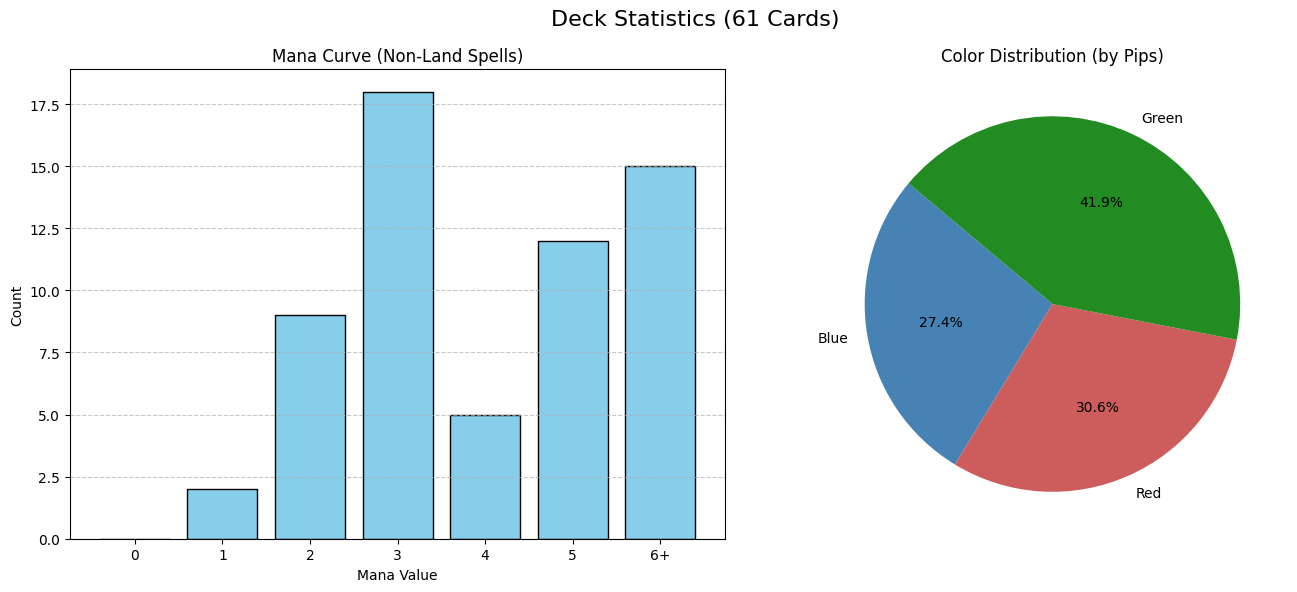

In [ ]:
import numpy as np
import random
import pandas as pd
import traceback
import os
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from google.colab import drive
from sklearn.metrics.pairwise import cosine_similarity

# --- Data Loading from Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Path configuration - Update this if your files are in a subfolder
DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
CSV_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
RAW_CSV_PATH = os.path.join(DRIVE_PATH, 'cleaned_mtg_card_features.csv')
NPY_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

print(f"Loading resources from {DRIVE_PATH}...")
try:
    if not os.path.exists(CSV_PATH) or not os.path.exists(NPY_PATH):
        raise FileNotFoundError(f"Files not found. Ensure 'model_ready_card_vectors.csv' and 'card_embeddings.npy' are in {DRIVE_PATH}")

    df = pd.read_csv(CSV_PATH)
    embeddings = np.load(NPY_PATH)

    # Load raw data for accurate visualization (unscaled mana values)
    if os.path.exists(RAW_CSV_PATH):
        raw_df = pd.read_csv(RAW_CSV_PATH)
        print(f"Raw data loaded for visualization. ({len(raw_df)} cards)")
    else:
        print("Warning: Raw data file not found. Visualizations may vary.")
        raw_df = df.copy() # Fallback

    # Initialize the model
    model = SentenceTransformer('all-mpnet-base-v2')
    print(f"Resources loaded successfully. Cards: {len(df)}")
except Exception as e:
    print(f"Critical Error loading resources: {e}")
    # Initialize empty to prevent definition errors, but execution will fail
    df = pd.DataFrame()
    raw_df = pd.DataFrame()
    embeddings = np.array([])
    model = None

# --- Visualization Function ---
def visualize_deck_stats(deck_names, df, raw_df=None):
    """
    Visualizes the Mana Curve and Color Distribution of a deck.
    Uses raw_df for unscaled mana values if provided.
    """
    # 1. Prepare Data for Mana Curve (Use Unscaled Data)
    target_df = raw_df if raw_df is not None and not raw_df.empty else df
    deck_raw = target_df[target_df['name'].isin(deck_names)].copy()

    if deck_raw.empty:
        print("No cards found to visualize.")
        return

    # Setup plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Deck Statistics ({len(deck_names)} Cards)', fontsize=16)

    # --- 1. Mana Curve (Bar Chart) ---
    # Round mana values to nearest int (handling .5s if any) and cap at 6+
    mana_values = deck_raw['mana_value'].fillna(0).round().astype(int)
    mana_counts = mana_values.value_counts().sort_index()

    # Ensure bins 0 through 6 exist
    curve_data = {i: 0 for i in range(7)}

    for mv, count in mana_counts.items():
        if mv >= 6:
            curve_data[6] += count
        elif mv >= 0:
            curve_data[mv] += count

    # Prepare data for plotting
    categories = [str(i) for i in range(6)] + ["6+"]
    counts = [curve_data[i] for i in range(7)]

    ax1.bar(categories, counts, color='skyblue', edgecolor='black')
    ax1.set_title('Mana Curve (Non-Land Spells)')
    ax1.set_xlabel('Mana Value')
    ax1.set_ylabel('Count')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- 2. Color Distribution (Pie Chart) ---
    # Use the processed df which has the CI_ columns
    deck_encoded = df[df['name'].isin(deck_names)].copy()

    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    color_labels = ['White', 'Blue', 'Black', 'Red', 'Green']
    color_map = {
        'White': '#F0E68C',
        'Blue': '#4682B4',
        'Black': '#A9A9A9',
        'Red': '#CD5C5C',
        'Green': '#228B22'
    }

    color_counts = []
    active_labels = []
    active_colors = []

    for col, label in zip(color_cols, color_labels):
        if col in deck_encoded.columns:
            count = deck_encoded[col].sum()
            if count > 0:
                color_counts.append(count)
                active_labels.append(label)
                active_colors.append(color_map[label])

    # Handle colorless decks
    if not color_counts:
        color_counts = [1]
        active_labels = ['Colorless']
        active_colors = ['#D3D3D3']

    ax2.pie(color_counts, labels=active_labels, colors=active_colors, autopct='%1.1f%%', startangle=140)
    ax2.set_title('Color Distribution (by Pips)')

    plt.tight_layout()
    plt.show()

# --- GA Helper Functions ---

def get_commander_color_identity(commander_name, df):
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander '{commander_name}' not found.")

    # Reconstruct ID from CI_ columns
    row = matches.iloc[0]
    colors = []
    for c in ['W', 'U', 'B', 'R', 'G']:
        if f'CI_{c}' in df.columns and row[f'CI_{c}'] == 1:
            colors.append(c)
    return ''.join(colors) if colors else 'C'

def filter_by_color_identity(commander_id, df):
    allowed = set(commander_id)
    mask = pd.Series([True] * len(df), index=df.index)
    for c in ['W', 'U', 'B', 'R', 'G']:
        if c not in allowed and f'CI_{c}' in df.columns:
            mask = mask & (df[f'CI_{c}'] == 0)
    return df[mask].copy()

def get_candidate_pool(prompt, filtered_df, embeddings_matrix, model, top_k=1000):
    if filtered_df.empty: return []
    prompt_vec = model.encode([prompt])
    filtered_indices = filtered_df.index.tolist()
    subset_embeddings = embeddings_matrix[filtered_indices]
    sims = cosine_similarity(prompt_vec, subset_embeddings).flatten()

    top_k = min(top_k, len(filtered_indices))
    best_local_indices = np.argsort(sims)[-top_k:][::-1]

    return [filtered_indices[i] for i in best_local_indices]

def create_individual(pool, target_size=61):
    return np.random.choice(pool, target_size, replace=False).tolist()

def crossover(p1, p2, target_size=61):
    split = np.random.randint(int(target_size*0.4), int(target_size*0.6))
    child = p1[:split]
    seen = set(child)
    for card in p2:
        if card not in seen:
            child.append(card)
            seen.add(card)
            if len(child) == target_size: break
    return child

def mutate(deck, pool, rate=0.05):
    deck_set = set(deck)
    pool = np.array(pool)
    for i in range(len(deck)):
        if np.random.rand() < rate:
            for _ in range(10):
                new_c = np.random.choice(pool)
                if new_c not in deck_set:
                    deck_set.remove(deck[i])
                    deck[i] = new_c
                    deck_set.add(new_c)
                    break
    return deck

def selection(pop, scores, top_k):
    inds = np.argsort(scores)[::-1][:top_k]
    return [pop[i] for i in inds]

def calculate_deck_optimization(deck, cmd_idx, embs, df):
    """
    Calculates a multi-factor optimization score for a 99-card deck.
    Modified to target 10 Ramp, 10 Draw, and 10 Interaction spells.
    """
    # 1. EXTRACT DATA
    if cmd_idx >= len(embs) or any(idx >= len(embs) for idx in deck):
        pass

    deck_vecs = embs[deck]
    cmd_vec = embs[cmd_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT (0.85 weight)
    comm_sims = cosine_similarity(cmd_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION (0.10 weight)
    cohesion_score = 0.0
    if len(deck_vecs) > 1:
        inner_sim_matrix = cosine_similarity(deck_vecs)
        triu_indices = np.triu_indices(len(deck_vecs), k=1)
        if triu_indices[0].size > 0:
            cohesion_score = np.mean(inner_sim_matrix[triu_indices])
        else:
            cohesion_score = 0.0

    # 4. ROLE SATISFACTION (0.05 weight)
    # Target: 10 Ramp, 10 Draw, 10 Interaction (Spot Removal + Wipes)
    roles_present = df.iloc[deck]

    def get_role_sum(col_name):
        return roles_present[col_name].sum() if col_name in roles_present.columns else 0

    ramp_count = get_role_sum('is_Ramp')
    draw_count = get_role_sum('is_Card_Draw')

    # Interaction covers Spot Removal and Board Wipes
    removal_count = get_role_sum('is_Spot_Removal')
    wipe_count = get_role_sum('is_Board_Wipe')
    interaction_count = removal_count + wipe_count

    # Score Saturation at 10 cards
    ramp_score = min(ramp_count / 10.0, 1.0)
    draw_score = min(draw_count / 10.0, 1.0)
    interaction_score = min(interaction_count / 10.0, 1.0)

    structure_score = (ramp_score + draw_score + interaction_score) / 3.0

    # 5. FINAL OPTIMIZATION SCORE
    # Balanced weights to ensure structure is respected
    final_score = (
        (alignment_score * 0.85) +
        (cohesion_score * 0.10) +
        (structure_score * 0.05)
    )

    return final_score

def calculate_land_distribution(deck_names, df, commander_identity, total_lands=38):
    """
    Calculates the land base, including 'Command Tower' and relevant dual lands
    for multicolored decks, then fills the rest with Basic Lands based on pip count.
    """
    # 1. Filter the global DataFrame for the cards in the deck
    deck_df = df[df['name'].isin(deck_names)]

    # 2. Define Basics Mapping
    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    land_names = ['Plains', 'Island', 'Swamp', 'Mountain', 'Forest']
    color_codes = ['W', 'U', 'B', 'R', 'G']

    final_lands = []
    current_land_count = 0

    # 3. Add Staples for Multicolored Decks
    unique_colors = set(commander_identity)
    is_multicolored = len(unique_colors) > 1

    if is_multicolored:
        staples = ["Command Tower", "Exotic Orchard"]
        for land in staples:
            if current_land_count < total_lands:
                final_lands.append(land)
                current_land_count += 1

    # 4. Add Dual Lands based on Color Pairs
    # Simple dictionary of affordable/staple duals for each pair
    DUAL_LANDS = {
        frozenset(['W', 'U']): ["Hallowed Fountain", "Glacial Fortress", "Azorius Chancery"],
        frozenset(['U', 'B']): ["Watery Grave", "Drowned Catacomb", "Dimir Aqueduct"],
        frozenset(['B', 'R']): ["Blood Crypt", "Dragonskull Summit", "Rakdos Carnarium"],
        frozenset(['R', 'G']): ["Stomping Ground", "Rootbound Crag", "Gruul Turf"],
        frozenset(['G', 'W']): ["Temple Garden", "Sunpetal Grove", "Selesnya Sanctuary"],
        frozenset(['W', 'B']): ["Godless Shrine", "Isolated Chapel", "Orzhov Basilica"],
        frozenset(['U', 'R']): ["Steam Vents", "Sulfur Falls", "Izzet Boilerworks"],
        frozenset(['B', 'G']): ["Overgrown Tomb", "Woodland Cemetery", "Golgari Rot Farm"],
        frozenset(['R', 'W']): ["Sacred Foundry", "Clifftop Retreat", "Boros Garrison"],
        frozenset(['G', 'U']): ["Breeding Pool", "Hinterland Harbor", "Simic Growth Chamber"]
    }

    if is_multicolored:
        # Check each pair in the dictionary
        for pair, duals in DUAL_LANDS.items():
            # If the commander contains BOTH colors of the pair
            if pair.issubset(unique_colors):
                # Add all duals from the list as long as total_lands is not reached
                for dual in duals:
                    if current_land_count < total_lands:
                        final_lands.append(dual)
                        current_land_count += 1

    # 5. Calculate Basics for the Remainder
    remaining_slots = total_lands - current_land_count

    if remaining_slots > 0:
        # Calculate "Pips"
        pip_counts = []
        for col in color_cols:
            if col in deck_df.columns:
                pip_counts.append(deck_df[col].sum())
            else:
                pip_counts.append(0)

        total_pips = sum(pip_counts)

        # Handle Colorless Case
        if total_pips == 0:
            final_lands.extend(['Wastes'] * remaining_slots)
        else:
            # Proportional Distribution
            land_counts = [int((count / total_pips) * remaining_slots) for count in pip_counts]

            # Adjust for Rounding
            current_sum = sum(land_counts)
            remainder = remaining_slots - current_sum
            if remainder > 0:
                # Distribute remainder to the colors with the highest pip counts
                # This ensures primary colors get slightly more land if needed
                sorted_pips_indices = np.argsort(pip_counts)[::-1] # indices of pips from high to low
                for i in range(remainder):
                    land_counts[sorted_pips_indices[i]] += 1

            # Append Basic Lands
            for count, name in zip(land_counts, land_names):
                final_lands.extend([name] * count)

    return final_lands

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, population_size=1000, mutation_rate=0.07, deck_size=61):
    print(f"--- Starting GA for: {commander_name} ---")

    # Setup Commander
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander not found.")

    cmd_idx = matches.index[0]
    cid = get_commander_color_identity(df.iloc[cmd_idx]['name'], df)
    legal_df = filter_by_color_identity(cid, df)

    pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(pool) < deck_size: raise ValueError("Pool too small.")

    pop = [create_individual(pool, deck_size) for _ in range(population_size)]

    best_score = -1
    best_deck = None

    for g in range(generations):
        scores = [calculate_deck_optimization(d, cmd_idx, embeddings, df) for d in pop]

        curr_best_idx = np.argmax(scores)
        if scores[curr_best_idx] > best_score:
            best_score = scores[curr_best_idx]
            best_deck = pop[curr_best_idx]

        if g % 10 == 0: print(f"Gen {g}: {best_score:.4f}")

        elites = selection(pop, scores, max(2, int(population_size*0.2)))
        next_gen = elites[:]
        while len(next_gen) < population_size:
            p1, p2 = random.sample(elites, 2)
            child = mutate(crossover(p1, p2, deck_size), pool, mutation_rate)
            next_gen.append(child)
        pop = next_gen

    print(f"Final Score: {best_score:.4f}")
    return df.iloc[best_deck]['name'].tolist()

# --- Wrapper ---
def generate_edh_deck(commander_name, prompt):
    if df.empty:
        print("Data not loaded. Cannot generate deck.")
        return []

    try:
        best_names = run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, deck_size=61)

        # Lands
        cid = get_commander_color_identity(commander_name, df)
        lands = calculate_land_distribution(best_names, df, cid, 38)

        final = best_names + lands

        print(f"\n--- Deck for {commander_name} ---")
        print(f"Theme: {prompt}")
        print("\n[Spells]")
        for n in best_names: print(n)
        print("\n[Lands]")
        for l in lands: print(l)

        # Pass the raw_df for accurate mana values
        visualize_deck_stats(best_names, df, raw_df)
        return final
    except Exception as e:
        print(f"Error: {e}")
        traceback.print_exc()
        return []

if __name__ == "__main__":
    final_deck = generate_edh_deck(
        commander_name="Averna, the Chaos Bloom",
        prompt="cascade"
    )

## EDHRec baseline test

Try to compare results to data from EDHRec


In [ ]:
!pip install pyedhrec
from pyedhrec import EDHRec
import re
import time

def clean_card_name(name):
    """
    Cleans card names by removing extra whitespace or specific set codes if present.
    """
    if not name:
        return ""
    # Remove text in parentheses (e.g., set codes or clarification)
    name = re.sub(r'\s*\([^)]*\)', '', name).strip()
    return name

def get_edhrec_baseline(commander_name):
    """
    Fetches a baseline list of cards (High Synergy, Top Cards, etc.) for a commander from EDHRec.
    Adapts to the dictionary structure where keys are section headers.
    """
    edh = EDHRec()

    # 1. Generate Slug
    name_for_slug = commander_name.split(' // ')[0] # Handles MDFCs by taking the first face
    name_for_slug = name_for_slug.replace("'", "").replace(",", "")
    slug = name_for_slug.lower().replace(' ', '-')
    slug = re.sub(r'-+', '-', slug) # Remove multiple hyphens

    print(f"Fetching EDHRec data for slug: {slug}...")

    try:
        # Introduce a small delay to avoid hitting API rate limits if called in quick succession
        time.sleep(0.5)
        data = edh.get_commander_cards(slug)

        baseline_cards = set()
        # Target headers that usually contain relevant cards for a baseline
        target_headers = [
            'High Synergy Cards', 'Top Cards', 'New Cards', # Primary sections
            'Creatures', 'Instants', 'Sorceries', 'Artifacts', 'Enchantments', 'Planeswalkers', 'Lands', # Card type sections
            'Utility Artifacts', 'Utility Lands', 'Mana Artifacts'
        ]

        if isinstance(data, dict):
            for header in target_headers:
                if header in data:
                    content = data[header]

                    # Helper to process a list of card objects
                    def process_card_list(clist):
                        for card in clist:
                            if isinstance(card, dict):
                                cname = clean_card_name(card.get('name'))
                                if cname:
                                    baseline_cards.add(cname)

                    if isinstance(content, list): # e.g., 'High Synergy Cards': [{'name': 'Card1'}, ...]
                        process_card_list(content)
                    elif isinstance(content, dict): # e.g., 'Creatures': {'cardviews': [{'name': 'Card1'}, ...]}
                        if 'cardviews' in content:
                            process_card_list(content['cardviews'])
                        elif 'cards' in content:
                            process_card_list(content['cards'])

        # Fallback for alternative structures (less common with pyedhrec current version but good to have)
        elif isinstance(data, list):
             for cl in data:
                if cl.get('header') in target_headers:
                    for card in cl.get('cardviews', []):
                        cname = clean_card_name(card.get('name'))
                        if cname:
                            baseline_cards.add(cname)

        unique_cards = list(baseline_cards)
        if unique_cards:
            print(f"Successfully fetched {len(unique_cards)} unique baseline cards.")
        else:
            print("No relevant cards found in EDHRec response for the specified commander/sections.")
        return unique_cards

    except Exception as e:
        print(f"Error fetching/parsing EDHRec data: {e}")
        # Optional: print traceback for detailed debugging in case of unexpected errors
        # import traceback
        # traceback.print_exc()
        return []

def calculate_similarity_stats(generated_deck, baseline_cards):
    gen_set = set(generated_deck)
    base_set = set(baseline_cards)
    intersection = gen_set.intersection(base_set)
    count = len(intersection)
    print(f"\n--- Similarity Stats ---")
    print(f"Matches found: {count}")
    if count > 0:
        sample = list(intersection)[:10]
        print(f"Matching Cards (Sample): {sample}")
    return count, list(intersection)

# --- Verification ---
if __name__ == '__main__':
    baseline = get_edhrec_baseline("Atraxa, Praetors' Voice")
    if baseline:
        print(f"First 10 baseline cards: {baseline[:10]}")

Fetching EDHRec data for slug: atraxa-praetors-voice...
Successfully fetched 285 unique baseline cards.
First 10 baseline cards: ['Phyrexian Atlas', 'Seaside Citadel', 'Viridian Corrupter', 'Jace, the Mind Sculptor', "Tezzeret's Gambit", 'Glistener Elf', 'Contagion Engine', 'Propaganda', 'Insight Engine', 'Inexorable Tide']


In [ ]:
import numpy as np
import random
from sklearn.metrics.pairwise import cosine_similarity

def calculate_deck_optimization(deck, cmd_idx, embs, df, weights=None):
    """
    Calculates a multi-factor optimization score for a 99-card deck.
    Now accepts a 'weights' dictionary for dynamic scoring.
    """
    # Default weights if none provided
    if weights is None:
        weights = {'alignment': 0.95, 'cohesion': 0.0, 'structure': 0.05}

    # 1. EXTRACT DATA
    # The function expects deck indices and commander index to be valid for embs and df
    # The error handling for out-of-bounds is usually done upstream during index generation.

    deck_vecs = embs[deck]
    cmd_vec = embs[cmd_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT
    # FIXED: cmd_vec was defined above, but comm_vec was used here. Fixed typo.
    comm_sims = cosine_similarity(cmd_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION
    cohesion_score = 0.0
    if len(deck_vecs) > 1:
        inner_sim_matrix = cosine_similarity(deck_vecs)
        triu_indices = np.triu_indices(len(deck_vecs), k=1)
        if triu_indices[0].size > 0:
            cohesion_score = np.mean(inner_sim_matrix[triu_indices])
        else:
            cohesion_score = 0.0

    # 4. ROLE SATISFACTION
    # Target: 10 Ramp, 10 Draw, 10 Interaction (Spot Removal + Wipes)
    roles_present = df.iloc[deck]

    def get_role_sum(col_name):
        return roles_present[col_name].sum() if col_name in roles_present.columns else 0

    ramp_count = get_role_sum('is_Ramp')
    draw_count = get_role_sum('is_Card_Draw')

    # Interaction covers Spot Removal and Board Wipes
    removal_count = get_role_sum('is_Spot_Removal')
    wipe_count = get_role_sum('is_Board_Wipe')
    interaction_count = removal_count + wipe_count

    # Score Saturation up to 12 cards, penalize over 12
    if ramp_count <= 12:
        ramp_score = min(ramp_count / 12.0, 1.0) # Linearly increases up to 1.0 at 12
    else:
        # Penalize if ramp_count exceeds 12. Score drops from 1.0.
        # Max penalty if count reaches 24 (12 + 12 = 24), score becomes 0.0
        ramp_score = max(0.0, 1.0 - (ramp_count - 12) / 12.0)

    if draw_count <= 12:
        draw_score = min(draw_count / 12.0, 1.0) # Linearly increases up to 1.0 at 12
    else:
        # Penalize if draw_count exceeds 12. Score drops from 1.0.
        draw_score = max(0.0, 1.0 - (draw_count - 12) / 12.0)

    # Interaction score remains capped at 1.0 at 10, as no specific penalty was requested for it.
    interaction_score = min(interaction_count / 10.0, 1.0)

    structure_score = (ramp_score + draw_score + interaction_score) / 3.0

    # 5. FINAL OPTIMIZATION SCORE using dynamic weights
    final_score = (
        (alignment_score * weights.get('alignment', 0.85)) +
        (cohesion_score * weights.get('cohesion', 0.10)) +
        (structure_score * weights.get('structure', 0.05))
    )

    return final_score

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model,
                          generations=30, population_size=1000, mutation_rate=0.07,
                          deck_size=61, weights=None):
    """
    Main loop for the EDH Deck Generation Genetic Algorithm.
    Now accepts 'weights' to pass down to the fitness function.
    """
    if weights is None:
        weights = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}

    print(f"--- Starting GA for: {commander_name} ---")
    print(f"Optimization Weights: {weights}")

    # Setup Commander
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander not found.")

    cmd_idx = matches.index[0]
    cid = get_commander_color_identity(df.iloc[cmd_idx]['name'], df)
    legal_df = filter_by_color_identity(cid, df)

    pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(pool) < deck_size: raise ValueError("Pool too small.")

    pop = [create_individual(pool, deck_size) for _ in range(population_size)]

    best_score = -1
    best_deck = None

    for g in range(generations):
        # Pass weights to fitness function
        scores = [calculate_deck_optimization(d, cmd_idx, embeddings, df, weights=weights) for d in pop]

        curr_best_idx = np.argmax(scores)
        if scores[curr_best_idx] > best_score:
            best_score = scores[curr_best_idx]
            best_deck = pop[curr_best_idx]

        if g % 10 == 0: print(f"Gen {g}: {best_score:.4f}")

        elites = selection(pop, scores, max(2, int(population_size*0.2)))
        next_gen = elites[:]
        while len(next_gen) < population_size:
            p1, p2 = random.sample(elites, 2)
            child = mutate(crossover(p1, p2, deck_size), pool, mutation_rate)
            next_gen.append(child)
        pop = next_gen

    print(f"Final Score: {best_score:.4f}")
    return df.iloc[best_deck]['name'].tolist()

# --- Test Block for Dynamic Weights ---
if __name__ == '__main__':
    print("\n--- Testing Dynamic Weights ---")
    try:
        # Check if df, embeddings, and model are already loaded from previous cells
        # These variables are expected to be global from cell 8331e8a4.
        if 'df' not in globals() or 'embeddings' not in globals() or 'model' not in globals():
            print("WARNING: Required data (df, embeddings, model) not found in global scope.")
            print("Please ensure the data loading and model initialization cells (e.g., cell 8331e8a4) are executed before running this test.")
            raise NameError("Required data (df, embeddings, model) are not defined.")

        # Ensure df is not empty for a valid test
        if df.empty:
            raise ValueError("DataFrame 'df' is empty. Cannot perform dummy test.")

        # Dummy setup - using the first card in the dataframe as commander for testing purposes
        dummy_cmd_idx = 0
        dummy_deck = list(range(1, min(62, len(df)))) # Create a dummy deck with valid indices
        if len(dummy_deck) < 1:
            raise ValueError("DataFrame 'df' too small to create dummy_deck for test.")

        # Standard weights
        w_std = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}
        score_std = calculate_deck_optimization(dummy_deck, dummy_cmd_idx, embeddings, df, weights=w_std)
        print(f"Standard Weights Score: {score_std:.4f}")

        # Alignment focus
        w_align = {'alignment': 1.0, 'cohesion': 0.0, 'structure': 0.0}
        score_align = calculate_deck_optimization(dummy_deck, dummy_cmd_idx, embeddings, df, weights=w_align)
        print(f"Alignment-Only Score: {score_align:.4f}")

        # Structure focus
        w_struct = {'alignment': 0.0, 'cohesion': 0.0, 'structure': 1.0}
        score_struct = calculate_deck_optimization(dummy_deck, dummy_cmd_idx, embeddings, df, weights=w_struct)
        print(f"Structure-Only Score: {score_struct:.4f}")

        if score_std != score_align:
             print("SUCCESS: Weights correctly influence score.")
        else:
             print("WARNING: Scores identical, check logic.")

    except NameError as ne:
        print(f"Test skipped due to missing data: {ne}")
    except Exception as e:
        print(f"Test failed: {e}")


--- Testing Dynamic Weights ---
Please ensure the data loading and model initialization cells (e.g., cell 8331e8a4) are executed before running this test.
Test skipped due to missing data: Required data (df, embeddings, model) are not defined.


A function to test the Genetic Algorithm multiple times with different fitness weight profiles. The purpose is to easily check which weight profile produces the most desirable decklist.


In [ ]:
import pandas as pd
import numpy as np

# 1. Define Weight Profiles
WEIGHT_PROFILES = {
    'Balanced': {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3},
    'Commander Focused': {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1},
    'Structure Focused': {'alignment': 0.1, 'cohesion': 0.1, 'structure': 0.8}
}

# 2. Experiment Function
def run_weight_experiment(commander_name, prompt, df, embeddings, model):
    """
    Runs the Genetic Algorithm multiple times using different fitness weight profiles.
    Returns a dictionary of results: {profile_name: [list_of_card_names]}.
    """
    results = {}

    print(f"\n=== Running Weight Experiment for {commander_name} ===")

    for profile_name, weights in WEIGHT_PROFILES.items():
        print(f"\n>> Running Profile: {profile_name}")
        print(f"Weights: {weights}")

        try:
            # Run GA with specific weights
            # Using smaller gen/pop size for speed in experiment
            deck_names = run_genetic_algorithm(
                commander_name=commander_name,
                prompt=prompt,
                df=df,
                embeddings=embeddings,
                model=model,
                generations=20,
                population_size=30,
                deck_size=61,
                weights=weights
            )

            results[profile_name] = deck_names
            print(f"Completed {profile_name}. Deck size: {len(deck_names)}")

        except Exception as e:
            print(f"Error running profile {profile_name}: {e}")
            results[profile_name] = []

    return results

# 3. Test Block
if __name__ == "__main__":
    # Ensure data is available from previous steps
    if 'df' in locals() and not df.empty:
        try:
            test_commander = "Toralf, God of Fury"
            test_prompt = "Big damage spells and red chaos"

            experiment_results = run_weight_experiment(
                test_commander,
                test_prompt,
                df,
                embeddings,
                model
            )

            print(f"\nExperiment Complete. Profiles generated: {list(experiment_results.keys())}")
        except Exception as e:
            print(f"Experiment Test Failed: {e}")
    else:
        print("Dataframes not loaded. Skipping test.")

Dataframes not loaded. Skipping test.


In [ ]:
#Synergy check
#Compares vectors to EDHRec synergy scores
!pip install pyedhrec
import pandas as pd
import os
from sentence_transformers import SentenceTransformer, util
from pyedhrec import EDHRec
from google.colab import drive
import re
import time

# 1. Setup
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define path to the file in Drive
# Assumes the file is in 'MTGCISE' folder in MyDrive
# Correcting the file name to the one generated by the feature engineering step
csv_path = '/content/drive/MyDrive/MTGCISE/model_ready_card_vectors.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded data from {csv_path}")
else:
    print(f"File not found at {csv_path}. Please check the path.")
    df = pd.DataFrame() # Create empty DF to prevent subsequent errors

edh = EDHRec()
model = SentenceTransformer('all-mpnet-base-v2') # Start with this one

def clean_card_name(name):
    """
    Cleans card names by removing extra whitespace or specific set codes if present.
    """
    if not name:
        return ""
    # Remove text in parentheses (e.g., set codes or clarification)
    name = re.sub(r'\s*\([^)]*\)', '', name).strip()
    return name

def validate_model_synergy(commander_name):
    if df.empty:
        print("Dataframe is empty. Cannot run validation.")
        return 0, 0

    print(f"Validating against: {commander_name}")

    # 2. Get high-synergy cards from EDHRec
    try:
        # Convert to slug (e.g., "Atraxa, Praetors' Voice" -> "atraxa-praetors-voice")
        slug = commander_name.lower().replace("'", "").replace(",", "").replace(" ", "-")
        # Remove double slashes if any (for MDFCs)
        slug = slug.split("//")[0].strip("-")

        print(f"Fetching EDHRec data for slug: {slug}...")
        time.sleep(0.5) # Add a small delay to prevent rate limiting
        data = edh.get_commander_cards(slug)

        synergy_names = set()
        # Target headers that usually contain relevant cards for a baseline
        target_headers = [
            'High Synergy Cards', 'Top Cards', 'New Cards', # Primary sections
            'Creatures', 'Instants', 'Sorceries', 'Artifacts', 'Enchantments', 'Planeswalkers', 'Lands', # Card type sections
            'Utility Artifacts', 'Utility Lands', 'Mana Artifacts'
        ]

        if isinstance(data, dict):
            for header in target_headers:
                if header in data:
                    content = data[header]

                    # Helper to process a list of card objects
                    def process_card_list(clist):
                        for card in clist:
                            if isinstance(card, dict):
                                cname = clean_card_name(card.get('name'))
                                if cname:
                                    synergy_names.add(cname)

                    if isinstance(content, list): # e.g., 'High Synergy Cards': [{'name': 'Card1'}, ...]
                        process_card_list(content)
                    elif isinstance(content, dict): # e.g., 'Creatures': {'cardviews': [{'name': 'Card1'}, ...]}
                        if 'cardviews' in content:
                            process_card_list(content['cardviews'])
                        elif 'cards' in content:
                            process_card_list(content['cards'])
        elif isinstance(data, list):
             for cl in data:
                if cl.get('header') in target_headers:
                    for card in cl.get('cardviews', []):
                        cname = clean_card_name(card.get('name'))
                        if cname:
                            synergy_names.add(cname)

        synergy_names = list(synergy_names)
        if not synergy_names:
            print("No cards found in EDHRec response.")
            return 0, 0

        print(f"Retrieved {len(synergy_names)} synergy candidates from EDHRec.")

    except Exception as e:
        print(f"Error fetching EDHRec data: {e}")
        import traceback
        traceback.print_exc()
        return 0, 0

    # 3. Create Embeddings
    # Get the text for the commander and the synergy cards
    # Use 'oracle_text_clean' if available, as per data prep steps
    text_col = 'oracle_text_clean' if 'oracle_text_clean' in df.columns else 'oracle_text'

    cmd_row = df[df['name'] == commander_name]
    if cmd_row.empty:
        # Try finding partial match if exact match fails
        cmd_row = df[df['name'].str.contains(commander_name, regex=False)]

    if cmd_row.empty:
        print(f"Commander '{commander_name}' not found in local CSV.")
        return 0, 0

    commander_text = cmd_row[text_col].iloc[0]

    # Filter for synergy cards present in our dataset
    synergy_df = df[df['name'].isin(synergy_names)]

    if synergy_df.empty:
        print("None of the synergy cards from EDHRec were found in the local dataset.")
        return 0, 0

    synergy_texts = synergy_df[text_col].tolist()

    # Baseline comparison (Random cards)
    random_texts = df.sample(len(synergy_texts))[text_col].tolist()

    cmd_vec = model.encode(commander_text, convert_to_tensor=True)
    syn_vecs = model.encode(synergy_texts, convert_to_tensor=True)
    rnd_vecs = model.encode(random_texts, convert_to_tensor=True)

    # 4. Calculate Scores
    avg_synergy_sim = util.cos_sim(cmd_vec, syn_vecs).mean().item()
    avg_random_sim = util.cos_sim(cmd_vec, rnd_vecs).mean().item()

    return avg_synergy_sim, avg_random_sim

# Run the test
if not df.empty:
    syn_score, rnd_score = validate_model_synergy("Atraxa, Praetors' Voice")

    print(f"\nResults:")
    print(f"Average Similarity (High Synergy): {syn_score:.4f}")
    print(f"Average Similarity (Random Cards): {rnd_score:.4f}")
    print(f"Model Accuracy Delta: {syn_score - rnd_score:.4f}")

KeyboardInterrupt: 

In [ ]:
!pip install pyedhrec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from pyedhrec import EDHRec
import random

def calculate_deck_optimization(deck_indices, commander_idx, embeddings, df_features):
    """
    Calculates a multi-factor optimization score for a 99-card deck.

    Args:
        deck_indices: List of indices (integers) for the 99 cards in the deck.
        commander_idx: Index (integer) of the Commander card.
        embeddings: The full NxD embedding matrix (numpy array).
        df_features: The DataFrame containing role columns (e.g., 'is_Ramp').

    Returns:
        float: A score between 0 and 1.
    """
    # 1. EXTRACT DATA
    # Ensure indices are valid
    if commander_idx >= len(embeddings) or any(idx >= len(embeddings) for idx in deck_indices):
        raise ValueError("Indices out of bounds of the embedding matrix.")

    deck_vecs = embeddings[deck_indices]
    comm_vec = embeddings[commander_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT (0.85 weight)
    # Average similarity of every card in the 99 to the Commander.
    comm_sims = cosine_similarity(comm_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION (0.10 weight)
    # Average similarity of every card to every OTHER card.
    inner_sim_matrix = cosine_similarity(deck_vecs)
    # Get upper triangle indices to avoid self-similarity (diagonal) and duplicates
    triu_indices = np.triu_indices(len(deck_indices), k=1)
    cohesion_score = np.mean(inner_sim_matrix[triu_indices])

    # 4. ROLE SATISFACTION (0.05 weight)
    # Checks if the deck meets basic structural needs.
    # We use the passed DataFrame to look up specific feature columns.
    roles_present = df_features.iloc[deck_indices]

    # Note: Column names must match those in 'model_ready_card_vectors.csv'
    # The previous step generated 'is_Ramp', 'is_Card_Draw', etc.
    ramp_count = roles_present['is_Ramp'].sum() if 'is_Ramp' in roles_present.columns else 0
    draw_count = roles_present['is_Card_Draw'].sum() if 'is_Card_Draw' in roles_present.columns else 0

    # Simple sigmoid-like saturation: 10-12 sources is usually ideal
    # We cap the score at 1.0 if they have 12 or more sources.
    ramp_score = min(ramp_count / 12.0, 1.0)
    draw_score = min(draw_count / 12.0, 1.0)

    structure_score = (ramp_score + draw_score) / 2.0

    # 5. FINAL OPTIMIZATION SCORE
    final_score = (
        (alignment_score * 0.85) +
        (cohesion_score * 0.10) +
        (structure_score * 0.05)
    )

    return final_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/MTGCISE
!git config --global user.email "necrofantasia@icloud.com"
!git config --global user.name "Lenfried"

##Change GA params here
params in main

In [2]:
import numpy as np
import random
import pandas as pd
import traceback
import os
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from google.colab import drive
from sklearn.metrics.pairwise import cosine_similarity
import collections # Import collections for Counter

# --- Data Loading from Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Path configuration - Update this if your files are in a subfolder
DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
CSV_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
RAW_CSV_PATH = os.path.join(DRIVE_PATH, 'cleaned_mtg_card_features.csv')
NPY_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

print(f"Loading resources from {DRIVE_PATH}...")
try:
    if not os.path.exists(CSV_PATH) or not os.path.exists(NPY_PATH):
        raise FileNotFoundError(f"Files not found. Ensure 'model_ready_card_vectors.csv' and 'card_embeddings.npy' are in {DRIVE_PATH}")

    df = pd.read_csv(CSV_PATH)
    embeddings = np.load(NPY_PATH)

    # Load raw data for accurate visualization (unscaled mana values)
    if os.path.exists(RAW_CSV_PATH):
        raw_df = pd.read_csv(RAW_CSV_PATH)
        print(f"Raw data loaded for visualization. ({len(raw_df)} cards)")
    else:
        print("Warning: Raw data file not found. Visualizations may vary.")
        raw_df = df.copy() # Fallback

    # Initialize the model
    model = SentenceTransformer('all-mpnet-base-v2')
    print(f"Resources loaded successfully. Cards: {len(df)}")
except Exception as e:
    print(f"Critical Error loading resources: {e}")
    # Initialize empty to prevent definition errors, but execution will fail
    df = pd.DataFrame()
    raw_df = pd.DataFrame()
    embeddings = np.array([])
    model = None

# --- Visualization Function ---
def visualize_deck_stats(deck_names, df, raw_df=None):
    """
    Visualizes the Mana Curve and Color Distribution of a deck.
    Uses raw_df for unscaled mana values if provided.
    """
    # 1. Prepare Data for Mana Curve (Use Unscaled Data)
    target_df = raw_df if raw_df is not None and not raw_df.empty else df
    deck_raw = target_df[target_df['name'].isin(deck_names)].copy()

    if deck_raw.empty:
        print("No cards found to visualize.")
        return

    # Setup plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Deck Statistics ({len(deck_names)} Cards)', fontsize=16)

    # --- 1. Mana Curve (Bar Chart) ---
    # Round mana values to nearest int (handling .5s if any) and cap at 6+
    mana_values = deck_raw['mana_value'].fillna(0).round().astype(int)
    mana_counts = mana_values.value_counts().sort_index()

    # Ensure bins 0 through 6 exist
    curve_data = {i: 0 for i in range(7)}

    for mv, count in mana_counts.items():
        if mv >= 6:
            curve_data[6] += count
        elif mv >= 0:
            curve_data[mv] += count

    # Prepare data for plotting
    categories = [str(i) for i in range(6)] + ["6+"]
    counts = [curve_data[i] for i in range(7)]

    ax1.bar(categories, counts, color='skyblue', edgecolor='black')
    ax1.set_title('Mana Curve (Non-Land Spells)')
    ax1.set_xlabel('Mana Value')
    ax1.set_ylabel('Count')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- 2. Color Distribution (Pie Chart) ---
    # Use the processed df which has the CI_ columns
    deck_encoded = df[df['name'].isin(deck_names)].copy()

    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    color_labels = ['White', 'Blue', 'Black', 'Red', 'Green']
    color_map = {
        'White': '#F0E68C',
        'Blue': '#4682B4',
        'Black': '#A9A9A9',
        'Red': '#CD5C5C',
        'Green': '#228B22'
    }

    color_counts = []
    active_labels = []
    active_colors = []

    for col, label in zip(color_cols, color_labels):
        if col in deck_encoded.columns:
            count = deck_encoded[col].sum()
            if count > 0:
                color_counts.append(count)
                active_labels.append(label)
                active_colors.append(color_map[label])

    # Handle colorless decks
    if not color_counts:
        color_counts = [1]
        active_labels = ['Colorless']
        active_colors = ['#D3D3D3']

    ax2.pie(color_counts, labels=active_labels, colors=active_colors, autopct='%1.1f%%', startangle=140)
    ax2.set_title('Color Distribution (by Pips)')

    plt.tight_layout()
    plt.show()

# --- GA Helper Functions ---

def get_commander_color_identity(commander_name, df):
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander '{commander_name}' not found.")

    # Reconstruct ID from CI_ columns
    row = matches.iloc[0]
    colors = []
    for c in ['W', 'U', 'B', 'R', 'G']:
        if f'CI_{c}' in df.columns and row[f'CI_{c}'] == 1:
            colors.append(c)
    return ''.join(colors) if colors else 'C'

def filter_by_color_identity(commander_id, df):
    allowed = set(commander_id)
    mask = pd.Series([True] * len(df), index=df.index)
    for c in ['W', 'U', 'B', 'R', 'G']:
        if c not in allowed and f'CI_{c}' in df.columns:
            mask = mask & (df[f'CI_{c}'] == 0)
    return df[mask].copy()

def get_candidate_pool(prompt, filtered_df, embeddings_matrix, model, top_k=1000):
    if filtered_df.empty: return []
    prompt_vec = model.encode([prompt])
    filtered_indices = filtered_df.index.tolist()
    subset_embeddings = embeddings_matrix[filtered_indices]
    sims = cosine_similarity(prompt_vec, subset_embeddings).flatten()

    top_k = min(top_k, len(filtered_indices))
    best_local_indices = np.argsort(sims)[-top_k:][::-1]

    return [filtered_indices[i] for i in best_local_indices]

def create_individual(pool, target_size=61):
    return np.random.choice(pool, target_size, replace=False).tolist()

def crossover(p1, p2, target_size=61):
    split = np.random.randint(int(target_size*0.4), int(target_size*0.6))
    child = p1[:split]
    seen = set(child)
    for card in p2:
        if card not in seen:
            child.append(card)
            seen.add(card)
            if len(child) == target_size: break
    return child

def mutate(deck, pool, rate=0.05):
    deck_set = set(deck)
    pool = np.array(pool)
    for i in range(len(deck)):
        if np.random.rand() < rate:
            for _ in range(10):
                new_c = np.random.choice(pool)
                if new_c not in deck_set:
                    deck_set.remove(deck[i])
                    deck[i] = new_c
                    deck_set.add(new_c)
                    break
    return deck

def selection(pop, scores, top_k):
    inds = np.argsort(scores)[::-1][:top_k]
    return [pop[i] for i in inds]

def calculate_deck_optimization(deck, cmd_idx, embs, df, weights=None):
    """
    Calculates a multi-factor optimization score for a 99-card deck.
    Modified to target 10 Ramp, 10 Draw, and 10 Interaction spells.
    Now accepts a 'weights' dictionary for dynamic scoring.
    """
    # Default weights if none provided
    if weights is None:
        weights = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}

    # 1. EXTRACT DATA
    if cmd_idx >= len(embs) or any(idx >= len(embs) for idx in deck):
        pass

    deck_vecs = embs[deck]
    cmd_vec = embs[cmd_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT (0.85 weight)
    comm_sims = cosine_similarity(cmd_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION (0.10 weight)
    cohesion_score = 0.0
    if len(deck_vecs) > 1:
        inner_sim_matrix = cosine_similarity(deck_vecs)
        triu_indices = np.triu_indices(len(deck_vecs), k=1)
        if triu_indices[0].size > 0:
            cohesion_score = np.mean(inner_sim_matrix[triu_indices])
        else:
            cohesion_score = 0.0

    # 4. ROLE SATISFACTION (0.05 weight)
    # Target: 10 Ramp, 10 Draw, 10 Interaction (Spot Removal + Wipes)
    roles_present = df.iloc[deck]

    def get_role_sum(col_name):
        return roles_present[col_name].sum() if col_name in roles_present.columns else 0

    ramp_count = get_role_sum('is_Ramp')
    draw_count = get_role_sum('is_Card_Draw')

    # Interaction covers Spot Removal and Board Wipes
    removal_count = get_role_sum('is_Spot_Removal')
    wipe_count = get_role_sum('is_Board_Wipe')
    interaction_count = removal_count + wipe_count

    # Score Saturation at 10 cards
    ramp_score = min(ramp_count / 10.0, 1.0)
    draw_score = min(draw_count / 10.0, 1.0)
    interaction_score = min(interaction_count / 10.0, 1.0)

    structure_score = (ramp_score + draw_score + interaction_score) / 3.0

    # 5. FINAL OPTIMIZATION SCORE
    # Balanced weights to ensure structure is respected
    final_score = (
        (alignment_score * weights.get('alignment', 0.85)) +
        (cohesion_score * weights.get('cohesion', 0.10)) +
        (structure_score * weights.get('structure', 0.05))
    )

    return final_score

def calculate_land_distribution(deck_names, df, commander_identity, total_lands=38):
    """
    Calculates the land base, including 'Command Tower' and relevant dual lands
    for multicolored decks, then fills the rest with Basic Lands based on pip count.
    """
    # 1. Filter the global DataFrame for the cards in the deck
    deck_df = df[df['name'].isin(deck_names)]

    # 2. Define Basics Mapping
    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    land_names = ['Plains', 'Island', 'Swamp', 'Mountain', 'Forest']
    color_codes = ['W', 'U', 'B', 'R', 'G']

    final_lands = []
    current_land_count = 0

    # 3. Add Staples for Multicolored Decks
    unique_colors = set(commander_identity)
    is_multicolored = len(unique_colors) > 1

    if is_multicolored:
        staples = ["Command Tower", "Exotic Orchard"]
        for land in staples:
            if current_land_count < total_lands:
                final_lands.append(land)
                current_land_count += 1

    # 4. Add Dual Lands based on Color Pairs
    # Simple dictionary of affordable/staple duals for each pair
    DUAL_LANDS = {
        frozenset(['W', 'U']): ["Hallowed Fountain", "Glacial Fortress", "Azorius Chancery"],
        frozenset(['U', 'B']): ["Watery Grave", "Drowned Catacomb", "Dimir Aqueduct"],
        frozenset(['B', 'R']): ["Blood Crypt", "Dragonskull Summit", "Rakdos Carnarium"],
        frozenset(['R', 'G']): ["Stomping Ground", "Rootbound Crag", "Gruul Turf"],
        frozenset(['G', 'W']): ["Temple Garden", "Sunpetal Grove", "Selesnya Sanctuary"],
        frozenset(['W', 'B']): ["Godless Shrine", "Isolated Chapel", "Orzhov Basilica"],
        frozenset(['U', 'R']): ["Steam Vents", "Sulfur Falls", "Izzet Boilerworks"],
        frozenset(['B', 'G']): ["Overgrown Tomb", "Woodland Cemetery", "Golgari Rot Farm"],
        frozenset(['R', 'W']): ["Sacred Foundry", "Clifftop Retreat", "Boros Garrison"],
        frozenset(['G', 'U']): ["Breeding Pool", "Hinterland Harbor", "Simic Growth Chamber"]
    }

    if is_multicolored:
        # Check each pair in the dictionary
        for pair, duals in DUAL_LANDS.items():
            # If the commander contains BOTH colors of the pair
            if pair.issubset(unique_colors):
                # Add all duals from the list as long as total_lands is not reached
                for dual in duals:
                    if current_land_count < total_lands:
                        final_lands.append(dual)
                        current_land_count += 1

    # 5. Calculate Basics for the Remainder
    remaining_slots = total_lands - current_land_count

    if remaining_slots > 0:
        # Calculate "Pips"
        pip_counts = []
        for col in color_cols:
            if col in deck_df.columns:
                pip_counts.append(deck_df[col].sum())
            else:
                pip_counts.append(0)

        total_pips = sum(pip_counts)

        # Handle Colorless Case
        if total_pips == 0:
            final_lands.extend(['Wastes'] * remaining_slots)
        else:
            # Proportional Distribution
            land_counts = [int((count / total_pips) * remaining_slots) for count in pip_counts]

            # Adjust for Rounding
            current_sum = sum(land_counts)
            remainder = remaining_slots - current_sum
            if remainder > 0:
                # Distribute remainder to the colors with the highest pip counts
                # This ensures primary colors get slightly more land if needed
                sorted_pips_indices = np.argsort(pip_counts)[::-1] # indices of pips from high to low
                for i in range(remainder):
                    land_counts[sorted_pips_indices[i]] += 1

            # Append Basic Lands
            for count, name in zip(land_counts, land_names):
                final_lands.extend([name] * count)

    return final_lands

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, population_size=1000, mutation_rate=0.07, deck_size=61, weights=None):
    """
    Main loop for the EDH Deck Generation Genetic Algorithm.
    Now accepts 'weights' to pass down to the fitness function.
    """
    if weights is None:
        weights = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}

    print(f"--- Starting GA for: {commander_name} ---")
    print(f"Optimization Weights: {weights}")

    # Setup Commander
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander not found.")

    cmd_idx = matches.index[0]
    cid = get_commander_color_identity(df.iloc[cmd_idx]['name'], df)
    legal_df = filter_by_color_identity(cid, df)

    pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(pool) < deck_size: raise ValueError("Pool too small.")

    pop = [create_individual(pool, deck_size) for _ in range(population_size)]

    best_score = -1
    best_deck = None

    for g in range(generations):
        # Pass weights to fitness function
        scores = [calculate_deck_optimization(d, cmd_idx, embeddings, df, weights=weights) for d in pop]

        curr_best_idx = np.argmax(scores)
        if scores[curr_best_idx] > best_score:
            best_score = scores[curr_best_idx]
            best_deck = pop[curr_best_idx]

        if g % 10 == 0: print(f"Gen {g}: {best_score:.4f}")

        elites = selection(pop, scores, max(2, int(population_size*0.2)))
        next_gen = elites[:]
        while len(next_gen) < population_size:
            p1, p2 = random.sample(elites, 2)
            child = mutate(crossover(p1, p2, deck_size), pool, mutation_rate)
            next_gen.append(child)
        pop = next_gen

    print(f"Final Score: {best_score:.4f}")
    return df.iloc[best_deck]['name'].tolist()

# --- Wrapper ---
def generate_edh_deck(
    commander_name, prompt,
    generations=30, population_size=40, mutation_rate=0.05, deck_size=61,
    weights={'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}
):
    if df.empty:
        print("Data not loaded. Cannot generate deck.")
        return []

    try:
        best_names = run_genetic_algorithm(
            commander_name, prompt, df, embeddings, model,
            generations=generations, population_size=population_size,
            mutation_rate=mutation_rate, deck_size=deck_size, weights=weights
        )

        # Lands
        cid = get_commander_color_identity(commander_name, df)
        lands = calculate_land_distribution(best_names, df, cid, 38)

        final = best_names + lands

        print(f"\n--- Deck for {commander_name} ---")
        print(f"Theme: {prompt}")

        print("\n[Spells]")
        spell_counts = collections.Counter(best_names)
        for card, count in spell_counts.most_common():
            print(f"{count} {card}")

        print("\n[Lands]")
        land_counts = collections.Counter(lands)
        for land, count in land_counts.most_common():
            print(f"{count} {land}")

        # Pass the raw_df for accurate mana values
        visualize_deck_stats(best_names, df, raw_df)
        return final
    except Exception as e:
        print(f"Error: {e}")
        traceback.print_exc()
        return []

if __name__ == "__main__":
    final_deck = generate_edh_deck(
        commander_name="Krenko, Mob Boss",
        prompt="Cards with the Goblin subtype and abilities that create Goblin creature tokens or provide stat buffs to Goblins",
        generations=50,
        population_size=1000,
        mutation_rate=0.05,
        deck_size=61,
        weights={'alignment': 0.85, 'cohesion': 0.1, 'structure': 0.05}
    )

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading resources from /content/drive/MyDrive/MTGCISE...
Raw data loaded for visualization. (30969 cards)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
!git add .
!git commit -m "Commit message"

In [ ]:
!git push origin main

## Greedy Baseline Function

Creates a deck by selecting the top 61 cards most similar to the prompt and then calculates a land base.


In [ ]:
def run_greedy_baseline(commander_name, prompt, df, embeddings, model):
    """
    Generates a baseline deck by greedily selecting the top 61 most similar cards to the prompt,
    WHILE prioritizing filling 10 Ramp, 10 Draw, and 10 Interaction slots first.
    """
    print(f"--- Running Structured Greedy Baseline for: {commander_name} ---")

    # 1. Identify Commander and Color Identity
    try:
        cid = get_commander_color_identity(commander_name, df)
    except ValueError as e:
        print(e)
        return []

    print(f"Commander Color Identity: {cid}")

    # 2. Filter for Legal Cards
    legal_df = filter_by_color_identity(cid, df)

    # 3. Get Candidate Pool based on Prompt Similarity (Top 1000 to have options)
    # We need a larger pool to find specific roles
    top_indices = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=2000)
    pool_df = df.iloc[top_indices].copy()

    # 4. Fill Functional Roles
    deck_indices = set()

    def select_best_for_role(role_col, count_needed, current_deck_indices):
        """Selects top cards for a role from the pool that aren't already in deck."""
        # Filter for cards that match the role and aren't in deck
        available = pool_df[
            (pool_df[role_col] == 1) &
            (~pool_df.index.isin(current_deck_indices))
        ]

        # Since pool_df is already sorted by similarity (from get_candidate_pool),
        # taking the top N gives us the most similar cards for that role.
        selected = available.head(count_needed).index.tolist()
        return selected

    # 4.1 Select Ramp (Target 10)
    ramp_ids = select_best_for_role('is_Ramp', 10, deck_indices)
    deck_indices.update(ramp_ids)

    # 4.2 Select Draw (Target 10)
    draw_ids = select_best_for_role('is_Card_Draw', 10, deck_indices)
    deck_indices.update(draw_ids)

    # 4.3 Select Interaction (Target 10 total: Spot Removal + Board Wipes)
    # We create a temporary column for interaction check
    # Ensure these columns are integer type before bitwise OR
    pool_df['is_Interaction'] = pool_df['is_Spot_Removal'].astype(int) | pool_df['is_Board_Wipe'].astype(int)
    interaction_ids = select_best_for_role('is_Interaction', 10, deck_indices)
    deck_indices.update(interaction_ids)

    print(f"Role Filling Stats: {len(ramp_ids)} Ramp, {len(draw_ids)} Draw, {len(interaction_ids)} Interaction")

    # 5. Fill Remainder to reach 61 Spells
    target_size = 61
    needed = target_size - len(deck_indices)

    if needed > 0:
        # Select top cards from pool that aren't in deck yet
        remaining = pool_df[~pool_df.index.isin(deck_indices)].head(needed).index.tolist()
        deck_indices.update(remaining)

    # Convert indices back to names
    # Ensure we preserve order of addition for "best fits" mostly, or sort by original similarity?
    # Let's keep them as a list
    final_indices = list(deck_indices)

    # Retrieve names
    spell_names = df.iloc[final_indices]['name'].tolist()

    # 6. Generate Land Base
    lands = calculate_land_distribution(spell_names, df, cid, total_lands=38)

    final_deck = spell_names + lands

    print(f"Greedy Baseline Generated: {len(final_deck)} cards")
    return final_deck

In [ ]:
commander_name = "Averna, the Chaos Bloom"
prompt = "cascade"

greedy_decklist = run_greedy_baseline(commander_name, prompt, df, embeddings, model)

print(f"\n--- Greedy Baseline Decklist for {commander_name} ({len(greedy_decklist)} cards) ---")
for i, card in enumerate(greedy_decklist):
    print(f"{i+1}. {card}")

--- Running Structured Greedy Baseline for: Averna, the Chaos Bloom ---
Commander Color Identity: URG
Role Filling Stats: 10 Ramp, 10 Draw, 10 Interaction
Greedy Baseline Generated: 99 cards

--- Greedy Baseline Decklist for Averna, the Chaos Bloom (99 cards) ---
1. Into the Time Vortex
2. Shardless Agent
3. Orcish Lumberjack
4. Wildsear, Scouring Maw
5. Mirrorshell Crab
6. Bill Ferny, Bree Swindler
7. Ancestral Knowledge
8. Goblin Coward Parade
9. Leaf-Crowned Elder
10. Wolf-Skull Shaman
11. Throes of Chaos
12. Thought Collapse
13. Heralds of Tzeentch
14. Forceful Denial
15. Aurora Phoenix
16. Mudbutton Clanger
17. Ingenuity Engine
18. Bigger on the Inside
19. Alchemist's Talent
20. Didn't Say Please
21. Ice Magic
22. Noise Marine
23. Waterspout Weavers
24. Rain of Riches
25. Iroh, Dragon of the West
26. Second Guess
27. Snowfall
28. Urabrask, Heretic Praetor
29. Countermand
30. Rocketeer Boostbuggy
31. Flamekin Herald
32. Cancel
33. Bloodbraid Challenger
34. Volcanic Torrent
35. Gala

##Compares Greedy and Genetic Algorithms

In [ ]:
def run_comparative_experiment(commander_name, prompt, df, embeddings, model, weights=None):
    """
    Runs both the Greedy Baseline and the Genetic Algorithm for a given commander/prompt.
    Compares them on: Fitness Score, Functional Categories, and EDHRec Overlap.
    """
    # 1. Define GA Parameters
    GA_PARAMS = {
        'generations': 50,
        'population_size': 1000,
        'mutation_rate': 0.05,
        'deck_size': 61
    }

    print(f"\n{'='*60}")
    print(f" COMPARATIVE EXPERIMENT: {commander_name}")
    print(f"{'='*60}")
    print(f"GA PARAMETERS:")
    for param, value in GA_PARAMS.items():
        print(f"  - {param}: {value}")
    print(f"{'='*60}")

    # 2. Run Greedy Baseline
    print("\n>> 1. Running Greedy Baseline...")
    greedy_deck_names = run_greedy_baseline(commander_name, prompt, df, embeddings, model)

    # 3. Run Genetic Algorithm
    print("\n>> 2. Running Genetic Algorithm...")
    ga_spell_names = run_genetic_algorithm(
        commander_name,
        prompt,
        df,
        embeddings,
        model,
        generations=GA_PARAMS['generations'],
        population_size=GA_PARAMS['population_size'],
        mutation_rate=GA_PARAMS['mutation_rate'],
        deck_size=GA_PARAMS['deck_size'],
        weights=weights
    )

    # Add lands to GA deck for full comparison
    try:
        cid = get_commander_color_identity(commander_name, df)
        ga_lands = calculate_land_distribution(ga_spell_names, df, cid, total_lands=38)
        ga_full_deck = ga_spell_names + ga_lands
    except Exception as e:
        print(f"Error calculating lands for GA deck: {e}")
        ga_full_deck = ga_spell_names

    # 4. Get EDHRec Baseline for Overlap Check
    print("\n>> 3. Fetching EDHRec Baseline...")
    edhrec_names = get_edhrec_baseline(commander_name)
    edhrec_set = set(edhrec_names)

    # 5. Helper to Calculate Metrics
    def get_deck_metrics(deck_list, commander_name, df, embeddings, weights=None):
        deck_df = df[df['name'].isin(deck_list)]
        valid_indices = deck_df.index.tolist()

        cmd_rows = df[df['name'] == commander_name]
        if cmd_rows.empty:
             cmd_rows = df[df['name'].str.startswith(commander_name + " //")]

        if not cmd_rows.empty and not deck_df.empty:
            cmd_idx = cmd_rows.index[0]
            try:
                fitness = calculate_deck_optimization(valid_indices, cmd_idx, embeddings, df, weights=weights)
            except Exception as e:
                print(f"Error calculating fitness: {e}")
                fitness = 0.0
        else:
            fitness = 0.0

        ramp = deck_df['is_Ramp'].sum() if 'is_Ramp' in deck_df.columns else 0
        draw = deck_df['is_Card_Draw'].sum() if 'is_Card_Draw' in deck_df.columns else 0
        interaction = (
            (deck_df['is_Spot_Removal'].sum() if 'is_Spot_Removal' in deck_df.columns else 0) +
            (deck_df['is_Board_Wipe'].sum() if 'is_Board_Wipe' in deck_df.columns else 0)
        )

        overlap = len(set(deck_list).intersection(edhrec_set))

        return {
            'Fitness': fitness,
            'Ramp': ramp,
            'Draw': draw,
            'Interaction': interaction,
            'EDHRec_Overlap': overlap
        }

    # 6. Calculate Metrics
    greedy_metrics = get_deck_metrics(greedy_deck_names, commander_name, df, embeddings, weights)
    ga_metrics = get_deck_metrics(ga_full_deck, commander_name, df, embeddings, weights)

    # 7. Print Summary
    print(f"\n{'='*60}")
    print(f" COMPARISON RESULTS: {commander_name}")
    print(f"{'='*60}")
    print(f"{'Metric':<20} | {'Greedy Baseline':<15} | {'Genetic Algorithm':<15}")
    print(f"{' -'*30}")

    for key in ['Fitness', 'Ramp', 'Draw', 'Interaction', 'EDHRec_Overlap']:
        g_val = greedy_metrics[key]
        ga_val = ga_metrics[key]

        if isinstance(g_val, float):
            g_str = f"{g_val:.4f}"
            ga_str = f"{ga_val:.4f}"
        else:
            g_str = str(g_val)
            ga_str = str(ga_val)

        print(f"{key:<20} | {g_str:<15} | {ga_str:<15}")
    print(f"{'='*60}\n")

    return {'Greedy': greedy_metrics, 'GA': ga_metrics}

In [ ]:
# Enter your commander name and prompt here
commander_name_input = "Averna, the Chaos Bloom"  # @param {type:"string"}
prompt_input = "cascade"  # @param {type:"string"}

# Run the comparative experiment with the specified inputs
results = run_comparative_experiment(
    commander_name=commander_name_input,
    prompt=prompt_input,
    df=df,
    embeddings=embeddings,
    model=model
)

##Weight profile testing for optimization score function
1.  Accepts a commander name and a prompt.
2.  Fetches the "average deck" list from EDHRec using `get_edhrec_baseline`.
3.  Defines a list of weight configurations to test (e.g., `Balanced`: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}, `Alignment Focus`: {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1}, etc.).
4.  Iterates through each weight profile, running `run_genetic_algorithm` to generate a deck for each.
5.  Compares each generated deck against the EDHRec average deck using set intersection to calculate an overlap score.
6.  Returns the results sorted by the highest overlap.

Call the `optimize_weights_against_average_deck` function with the specified commander and prompt to demonstrate the optimization process and see which weight profile performs best against the EDHRec baseline.

Replace `commander_name` and `prompt` with any commander and prompt.


In [ ]:
!pip install pyedhrec
import pandas as pd
import numpy as np
import os
from sentence_transformers import SentenceTransformer
from pyedhrec import EDHRec
import re
import time

# --- Ensure Data is Loaded ---
if 'df' not in locals():
    print("Variables not found in local scope. Attempting to load...")
    DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
    CSV_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
    NPY_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

    if os.path.exists(CSV_PATH) and os.path.exists(NPY_PATH):
        try:
            df = pd.read_csv(CSV_PATH)
            embeddings = np.load(NPY_PATH)
            model = SentenceTransformer('all-mpnet-base-v2')
            print("Data loaded successfully.")
        except Exception as e:
            print(f"Error loading data: {e}")
            df = pd.DataFrame()
            embeddings = np.array([])
            model = None
    else:
        print("Data files not found. Please ensure Google Drive is mounted and paths are correct.")
        df = pd.DataFrame()
        embeddings = np.array([])
        model = None

# --- Helper Functions (EDHRec) ---
def clean_card_name(name):
    """
    Cleans card names by removing extra whitespace or specific set codes if present.
    """
    if not name:
        return ""
    # Remove text in parentheses (e.g., set codes or clarification)
    name = re.sub(r'\s*\([^)]*\)', '', name).strip()
    return name

def get_edhrec_baseline(commander_name):
    """
    Fetches a baseline list of cards (High Synergy, Top Cards, etc.) for a commander from EDHRec.
    """
    edh = EDHRec()

    # Generate Slug
    name_for_slug = commander_name.split(' // ')[0]
    name_for_slug = name_for_slug.replace("'", "").replace(",", "")
    slug = name_for_slug.lower().replace(' ', '-')
    slug = re.sub(r'-+', '-', slug)

    print(f"Fetching EDHRec data for slug: {slug}...")

    try:
        time.sleep(0.5)
        data = edh.get_commander_cards(slug)

        baseline_cards = set()
        target_headers = [
            'High Synergy Cards', 'Top Cards', 'New Cards',
            'Creatures', 'Instants', 'Sorceries', 'Artifacts', 'Enchantments', 'Planeswalkers', 'Lands',
            'Utility Artifacts', 'Utility Lands', 'Mana Artifacts'
        ]

        if isinstance(data, dict):
            for header in target_headers:
                if header in data:
                    content = data[header]
                    def process_card_list(clist):
                        for card in clist:
                            if isinstance(card, dict):
                                cname = clean_card_name(card.get('name'))
                                if cname:
                                    baseline_cards.add(cname)
                    if isinstance(content, list):
                        process_card_list(content)
                    elif isinstance(content, dict):
                        if 'cardviews' in content:
                            process_card_list(content['cardviews'])
                        elif 'cards' in content:
                            process_card_list(content['cards'])
        elif isinstance(data, list):
             for cl in data:
                if cl.get('header') in target_headers:
                    for card in cl.get('cardviews', []):
                        cname = clean_card_name(card.get('name'))
                        if cname:
                            baseline_cards.add(cname)

        unique_cards = list(baseline_cards)
        print(f"Successfully fetched {len(unique_cards)} unique baseline cards.")
        return unique_cards

    except Exception as e:
        print(f"Error fetching/parsing EDHRec data: {e}")
        return []

# --- Optimization Function ---
def optimize_weights_against_average_deck(commander_name, prompt, df, embeddings, model):
    """
    Tests multiple GA weight profiles against an EDHRec average deck baseline.
    Returns a sorted list of results based on overlap count.
    """
    if df.empty or model is None:
        print("Dataframe is empty or model is missing. Cannot run optimization.")
        return []

    print(f"\n{'='*60}")
    print(f" WEIGHT OPTIMIZATION: {commander_name}")
    print(f"{'='*60}")

    # 1. Get EDHRec Baseline
    print("\n>> Fetching EDHRec Baseline...")
    edhrec_names = get_edhrec_baseline(commander_name)
    if not edhrec_names:
        print("Failed to fetch baseline. Aborting.")
        return []
    edhrec_set = set(edhrec_names)
    print(f"Baseline size: {len(edhrec_set)} cards")

    # 2. Define Weight Profiles
    weight_profiles = {
        'Balanced': {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3},
        'Balanced 2': {'alignment': 0.5, 'cohesion': 0.3, 'structure': 0.2},
        'Balanced 3': {'alignment': 0.3, 'cohesion': 0.4, 'structure': 0.3},
        'Alignment Focus': {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1},
        'Alignment 2': {'alignment': 0.6, 'cohesion': 0.2, 'structure': 0.2},
        'Alignment 3': {'alignment': 0.7, 'cohesion': 0.2, 'structure': 0.1},
        'Alignment 4': {'alignment': 0.9, 'cohesion': 0.05, 'structure': 0.05},
        'Alignment 5:': {'alignment': 0.95, 'cohesion': 0.05, 'structure': 0.0},
        'Alignment 6': {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1},
        'Alignment 7': {'alignment': 0.85, 'cohesion': 0.1, 'structure': 0.05},
        'Structure Focus': {'alignment': 0.2, 'cohesion': 0.2, 'structure': 0.6},
        'Structure 2': {'alignment': 0.2, 'cohesion': 0.1, 'structure': 0.7},
        'Structure 3': {'alignment': 0.3, 'cohesion': 0.2, 'structure': 0.5}

    }

    results = []

    # 3. Iterate and Test
    for profile_name, weights in weight_profiles.items():
        print(f"\n>> Testing Profile: {profile_name}")
        print(f"Weights: {weights}")

        try:
            ga_deck_names = run_genetic_algorithm(
                commander_name, prompt, df, embeddings, model,
                generations=50, population_size=1000, deck_size=61, weights=weights
            )

            intersection = set(ga_deck_names).intersection(edhrec_set)
            overlap_count = len(intersection)

            results.append({
                'profile': profile_name,
                'weights': weights,
                'overlap': overlap_count,
                'deck': ga_deck_names
            })
            print(f"Overlap with EDHRec: {overlap_count}")

        except Exception as e:
            print(f"Error testing profile {profile_name}: {e}")

    # 4. Sort and Summary
    results.sort(key=lambda x: x['overlap'], reverse=True)

    print(f"\n{'='*60}")
    print(f" OPTIMIZATION RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"{'Profile Name':<20} | {'Overlap Count':<15}")
    print(f"{'-'*40}")

    for res in results:
        print(f"{res['profile']:<20} | {res['overlap']:<15}")
    print(f"{'='*60}\n")

    return results

if __name__ == "__main__":
    # Run the optimization test
    optimization_results = optimize_weights_against_average_deck(
        commander_name="Krenko, Mob Boss",
        prompt="Cards with the Goblin subtype and abilities that create Goblin creature tokens or provide stat buffs to Goblins",
        df=df,
        embeddings=embeddings,
        model=model
    )


ERROR: Operation cancelled by user

 WEIGHT OPTIMIZATION: Krenko, Mob Boss

>> Fetching EDHRec Baseline...
Fetching EDHRec data for slug: krenko-mob-boss...
Successfully fetched 219 unique baseline cards.
Baseline size: 219 cards

>> Testing Profile: Balanced
Weights: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}
--- Starting GA for: Krenko, Mob Boss ---
Optimization Weights: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}
Gen 0: 0.5123
Gen 10: 0.5772
Gen 20: 0.6056
Gen 30: 0.6143
Gen 40: 0.6170
Final Score: 0.6227
Overlap with EDHRec: 9

>> Testing Profile: Balanced 2
Weights: {'alignment': 0.5, 'cohesion': 0.3, 'structure': 0.2}
--- Starting GA for: Krenko, Mob Boss ---
Optimization Weights: {'alignment': 0.5, 'cohesion': 0.3, 'structure': 0.2}
Gen 0: 0.4777
Gen 10: 0.5367
Gen 20: 0.5558
Gen 30: 0.5707
Gen 40: 0.5777


KeyboardInterrupt: 

In [ ]:
#Prints the decklist of any profile for evaluation
for result in optimization_results:
    #Replace with the name of the profile desired
    if result['profile'] == 'Alignment 7':
        print(f"Deck generated by '{result['profile']}' profile (Overlap: {result['overlap']} cards):")
        for i, card_name in enumerate(result['deck'], 1):
            print(f"{i}. {card_name}")
        break


##EDHRec Average Deck and fitness score calculation

In [ ]:
import re
import time
import numpy as np
from pyedhrec import EDHRec

def get_edhrec_average_and_score(commander_name):
    """
    Fetches the average deck for a commander from EDHRec and calculates its
    optimization score using the existing fitness function.
    """
    edh = EDHRec()

    # 1. Generate Slug
    name_for_slug = commander_name.split(' // ')[0]
    slug = name_for_slug.lower().replace("'", "").replace(",", "").replace(" ", "-")
    slug = re.sub(r'-+', '-', slug)

    print(f"Fetching EDHRec data for: {commander_name} (slug: {slug})")

    try:
        time.sleep(0.5)
        data = edh.get_commanders_average_deck(slug)

        decklist = data.get("decklist", [])
        baseline_data = {} # Map cleaned name to original quantity string

        if decklist:
            for item in decklist:
                raw_name = ""
                if isinstance(item, dict) and 'name' in item:
                    raw_name = item['name']
                elif isinstance(item, str):
                    raw_name = item

                if raw_name:
                    # Extract quantity (e.g., '1' or '10')
                    qty_match = re.match(r'^(\d+)\s+', raw_name)
                    qty = qty_match.group(1) if qty_match else "1"

                    # Clean name for matching
                    clean_name = re.sub(r'^\d+\s+', '', raw_name)
                    clean_name = re.sub(r'\s*\([^)]*\)', '', clean_name).strip()

                    baseline_data[clean_name.lower()] = f"{qty} {clean_name}"

        # 3. Robust Mapping to local DataFrame indices
        df['name_clean'] = df['name'].str.lower().str.strip()
        baseline_names_lower = list(baseline_data.keys())

        deck_df = df[df['name_clean'].isin(baseline_names_lower)]
        deck_indices = [int(idx) for idx in deck_df.index.tolist()]

        # 4. Identify Commander Index
        cmd_name_lower = commander_name.lower().strip()
        cmd_matches = df[df['name_clean'] == cmd_name_lower]
        if cmd_matches.empty:
            cmd_matches = df[df['name_clean'].str.startswith(cmd_name_lower + " //")]

        if cmd_matches.empty:
            print(f"Warning: Commander '{commander_name}' not found in local dataset.")
            return 0.0, list(baseline_data.values())

        commander_idx = int(cmd_matches.index[0])

        # 5. Calculate Optimization Score
        if not deck_indices:
            print("No cards from the EDHRec average deck were found in the local dataset.")
            return 0.0, list(baseline_data.values())

        score = calculate_deck_optimization(deck_indices, commander_idx, embeddings, df)

        print(f"Average Deck Optimization Score: {score:.4f}")
        print(f"Matched {len(deck_indices)} cards in local dataset.")

        return score, sorted(list(baseline_data.values()))

    except Exception as e:
        print(f"Error fetching or scoring average deck: {e}")
        import traceback
        traceback.print_exc()
        return 0.0, []

# Standard execution for Averna to populate the namespace
test_commander_name = 'Averna, the Chaos Bloom'
score, cards = get_edhrec_average_and_score(test_commander_name)

Fetching EDHRec data for: Averna, the Chaos Bloom (slug: averna-the-chaos-bloom)
Average Deck Optimization Score: 0.4359
Matched 85 cards in local dataset.


##Computes GA and EDHRec similarity
Computes the cosine similarity between decks produced by GA and EDHRec average deck for a given commander

In [ ]:
!pip install pyedhrec
def compare_ga_vs_edhrec_similarity(commander_name, prompt, df, embeddings, model, ga_params=None):
    """
    Computes the average cosine similarity between the Genetic Algorithm deck
    (including generated lands and the commander) and the EDHRec Average Deck,
    accounting for card quantities (multiples of basics).
    """
    if ga_params is None:
        ga_params = {'generations': 30, 'population_size': 1000, 'deck_size': 61}

    print(f"--- Comparing GA Similarity to EDHRec Average for {commander_name} ---")

    # 1. Run the Genetic Algorithm to get spell names
    ga_spells = run_genetic_algorithm(
        commander_name,
        prompt,
        df,
        embeddings,
        model,
        **ga_params
    )

    # 2. Generate Lands for the GA deck
    cid = get_commander_color_identity(commander_name, df)
    ga_lands = calculate_land_distribution(ga_spells, df, cid, total_lands=38)

    # 3. Combine into full 100-card list (Commander + 99 cards)
    ga_full_deck = [commander_name] + ga_spells + ga_lands

    # 4. Fetch the EDHRec Average Deck
    _, edhrec_avg_raw = get_edhrec_average_and_score(commander_name)

    # 5. Helper to extract embeddings accounting for quantities
    def get_weighted_embeddings(raw_list, df_ref, embs_ref):
        weighted_embs = []
        df_temp = df_ref.copy()
        df_temp['name_lower'] = df_temp['name'].str.lower()

        for item in raw_list:
            # Extract quantity and name (e.g., \"20 Plains\" or \"1 Sol Ring\")
            match_qty = re.match(r'^(\d+)\s+(.*)$', item)
            if match_qty:
                qty = int(match_qty.group(1))
                name = match_qty.group(2).strip().lower()
            else:
                qty = 1
                name = item.strip().lower()

            # Find the card in local database
            card_match = df_temp[df_temp['name_lower'] == name]
            if not card_match.empty:
                idx = card_match.index[0]
                if idx < len(embs_ref):
                    # Append the embedding 'qty' times for 1-to-1 comparison
                    for _ in range(qty):
                        weighted_embs.append(embs_ref[idx])

        return np.array(weighted_embs)
#to check
    # Format GA deck for the weighted helper
    ga_formatted = [f"1 {name}" for name in ga_full_deck]

    ga_embs = get_weighted_embeddings(ga_formatted, df, embeddings)
    edhrec_embs = get_weighted_embeddings(edhrec_avg_raw, df, embeddings)

    if len(ga_embs) == 0 or len(edhrec_embs) == 0:
        print("Error: Could not retrieve embeddings for one of the decks.")
        return 0.0

    # 6. Calculate pairwise average cosine similarity
    # This now reflects the full 100 vs 100 card comparison
    sim_matrix = cosine_similarity(ga_embs, edhrec_embs)
    avg_sim = np.mean(sim_matrix)

    best_match_score = sim_matrix.max(axis=1).mean()

    # GA → EDHRec best match
    ga_to_edhrec = sim_matrix.max(axis=1).mean()

    # EDHRec → GA best match
    edhrec_to_ga = sim_matrix.max(axis=0).mean()

    # Symmetric similarity
    avg_sim_2 = 0.5 * (ga_to_edhrec + edhrec_to_ga)

    print(f"\nGA (100) vs EDHRec Average (100)")
    print(f"Cosine Similarity (Pair-wise): {avg_sim:.4f}")
    print(f"Cosine Similarity (Best-match):{best_match_score:.4f}")
    print(f"Cosine Symmetry Similarity (Best-match):{avg_sim_2:.4f}")
    print(f"(Calculated using {len(ga_embs)} GA card instances and {len(edhrec_embs)} EDHRec card instances)")

    return avg_sim

# --- Execution Wrapper ---
if __name__ == "__main__":
    commander_to_test = "Krenko, Mob Boss"
    prompt_to_test = "Cards with the Goblin subtype and abilities that create Goblin creature tokens or provide stat buffs to Goblins."

    ga_settings = {'generations': 30, 'population_size': 1000, 'deck_size': 61}

    try:
        similarity_score = compare_ga_vs_edhrec_similarity(
            commander_to_test,
            prompt_to_test,
            df,
            embeddings,
            model,
            ga_params=ga_settings
        )
    except Exception as e:
        print(f"Execution failed: {e}")

Execution failed: name 'df' is not defined


In [ ]:
def compare_ga_vs_edhrec_nonland_similarity(commander_name, prompt, df, embeddings, model, ga_params=None):
    """
    Computes the average cosine similarity between the Genetic Algorithm deck's spells
    (non-land cards) and the EDHRec Average Deck's spells, filtering out PURE lands.
    """
    if ga_params is None:
        ga_params = {'generations': 30, 'population_size': 1000, 'deck_size': 61}

    print(f"--- Comparing GA Spells Similarity to EDHRec Average Spells for {commander_name} ---")

    # 1. Run the Genetic Algorithm to get spell names (61 cards)
    ga_spells = run_genetic_algorithm(
        commander_name,
        prompt,
        df,
        embeddings,
        model,
        **ga_params
    )

    # 2. Fetch the EDHRec Average Deck
    _, edhrec_avg_raw = get_edhrec_average_and_score(commander_name)

    # 3. Identify PURE lands (exclude spells that are also lands like MDFCs)
    # We only want to filter cards that are JUST lands.
    spell_types = ['Creature', 'Instant', 'Sorcery', 'Artifact', 'Enchantment', 'Planeswalker']
    all_land_names = set(raw_df[
        (raw_df['type_line'].str.contains('Land', na=False)) &
        (~raw_df['type_line'].str.contains('|'.join(spell_types), na=False))
    ]['name'].tolist())

    # 4. Helper to extract embeddings for true non-lands only
    def get_true_spell_embeddings(raw_list, df_ref, embs_ref, source_label):
        weighted_embs = []
        found_names = []
        df_temp = df_ref.copy()

        for item in raw_list:
            match_qty = re.match(r'^(\d+)\s+(.*)$', item)
            if match_qty:
                qty = int(match_qty.group(1))
                name = match_qty.group(2).strip()
            else:
                qty = 1
                name = item.strip()

            # Skip only if the card is a PURE Land (no spell types)
            if name in all_land_names:
                continue

            card_match = df_temp[df_temp['name'] == name]
            if not card_match.empty:
                idx = card_match.index[0]
                if idx < len(embs_ref):
                    for _ in range(qty):
                        weighted_embs.append(embs_ref[idx])
                    found_names.append(name)
            else:
                # Avoid printing warnings for obvious basics that aren't in the model_ready CSV
                if name.lower() not in ['plains', 'island', 'swamp', 'mountain', 'forest', 'wastes']:
                    print(f"[Warning] {source_label} card not found in local DB: {name}")

        return np.array(weighted_embs), found_names

    # 5. Process both lists
    ga_formatted = [f"1 {name}" for name in ga_spells]

    ga_embs, ga_final_names = get_true_spell_embeddings(ga_formatted, df, embeddings, "GA")
    edhrec_embs, edhrec_final_names = get_true_spell_embeddings(edhrec_avg_raw, df, embeddings, "EDHRec")

    print(f"\nCounts after filtering PURE lands and verifying DB matches:")
    print(f"- GA spells target: {ga_params['deck_size']} | Actual processed: {len(ga_final_names)}")
    print(f"- EDHRec spells found: {len(edhrec_final_names)}")

    if len(ga_embs) == 0 or len(edhrec_embs) == 0:
        print("Error: Could not retrieve spell embeddings for comparison.")
        return 0.0

    # 6. Calculate similarities
    sim_matrix = cosine_similarity(ga_embs, edhrec_embs)
    avg_sim = np.mean(sim_matrix)

    best_match_score = sim_matrix.max(axis=1).mean()

    # GA → EDHRec best match
    ga_to_edhrec = sim_matrix.max(axis=1).mean()

    # EDHRec → GA best match
    edhrec_to_ga = sim_matrix.max(axis=0).mean()

    # Symmetric similarity
    avg_sim_2 = 0.5 * (ga_to_edhrec + edhrec_to_ga)

    print(f"\nGA (100) vs EDHRec Average (100)")
    print(f"Cosine Similarity (Pair-wise): {avg_sim:.4f}")
    print(f"Cosine Similarity (Best-match):{best_match_score:.4f}")
    print(f"Cosine Symmetry Similarity (Best-match):{avg_sim_2:.4f}")
    print(f"(Calculated using {len(ga_embs)} GA card instances and {len(edhrec_embs)} EDHRec card instances)")

# --- Example Run ---
if __name__ == '__main__':
    res = compare_ga_vs_edhrec_nonland_similarity(
        'Krenko, Mob Boss',
        'Cards with the Goblin subtype and abilities that create Goblin creature tokens or provide stat buffs to Goblins',
        df,
        embeddings,
        model
    )

In [ ]:
# Analyze the composition of the EDHRec average deck
# Using 'test_commander_name' which is defined globally as 'Averna, the Chaos Bloom'
_, edhrec_avg_raw = get_edhrec_average_and_score(test_commander_name)

# 1. Extract card names from the EDHRec list (stripping the leading quantity, e.g., '1 Sol Ring')
edhrec_names_only = [re.sub(r'^\d+\s+', '', name).strip() for name in edhrec_avg_raw]

# 2. Use 'raw_df' to identify which of these are actually lands (since 'df' had 'type_line' dropped)
# We check the 'type_line' for the word 'Land'
all_cards_in_avg_metadata = raw_df[raw_df['name'].isin(edhrec_names_only)]
land_names = all_cards_in_avg_metadata[all_cards_in_avg_metadata['type_line'].str.contains('Land', na=False)]['name'].tolist()

# 3. Filter the original list to exclude any card identified as a land
non_lands = [card for card in edhrec_avg_raw if re.sub(r'^\d+\s+', '', card).strip() not in land_names]

print(f"Total items in EDHRec 'Average' list: {len(edhrec_avg_raw)}")
print(f"Total non-land spells (True Spells) in EDHRec list: {len(non_lands)}")

print("\n--- EDHRec Average Deck True Spell List ---")
for i, card in enumerate(non_lands, 1):
    print(f"{i}. {card}")

# 4. Check role distribution in the EDHRec average deck for these spells
true_spell_names = [re.sub(r'^\d+\s+', '', card).strip() for card in non_lands]
edhrec_spells_df = df[df['name'].isin(true_spell_names)]

metrics = {
    'Ramp': edhrec_spells_df['is_Ramp'].sum(),
    'Draw': edhrec_spells_df['is_Card_Draw'].sum(),
    'Removal': edhrec_spells_df['is_Spot_Removal'].sum() + edhrec_spells_df['is_Board_Wipe'].sum()
}

import pandas as pd
display(pd.DataFrame([metrics], index=['EDHRec Average Deck Counts']))

print("\nThis filter now removes non-basic lands like Command Tower and dual lands.")
print("The count should now be much closer to the GA target of 61.")

##Compare GA EDHRec of different commanders

In [ ]:
def compare_cross_commander_similarity(ga_commander, ga_prompt, edhrec_commander, df, embeddings, model, ga_params=None):
    """
    Compares a GA-generated deck for one commander against the EDHRec average deck of potentially
    a different commander
    """
    if ga_params is None:
        ga_params = {'generations': 30, 'population_size': 1000, 'deck_size': 61}

    print(f"--- Cross-Commander Comparison ---")
    print(f"GA Deck: {ga_commander} (Theme: {ga_prompt})")
    print(f"EDHRec Baseline: {edhrec_commander}")

    # 1. Run GA for the first commander
    ga_spells = run_genetic_algorithm(
        ga_commander, ga_prompt, df, embeddings, model, **ga_params
    )

    # 2. Fetch EDHRec Average Deck for the second commander
    _, edhrec_avg_raw = get_edhrec_average_and_score(edhrec_commander)

    # 3. Helper for weighted embeddings
    def get_weighted_embeddings(raw_list, df_ref, embs_ref):
        weighted_embs = []
        df_temp = df_ref.copy()
        df_temp['name_lower'] = df_temp['name'].str.lower()

        for item in raw_list:
            match_qty = re.match(r'^(\d+)\s+(.*)$', item)
            qty, name = (int(match_qty.group(1)), match_qty.group(2).strip().lower()) if match_qty else (1, item.strip().lower())

            card_match = df_temp[df_temp['name_lower'] == name]
            if not card_match.empty:
                idx = card_match.index[0]
                for _ in range(qty): weighted_embs.append(embs_ref[idx])
        return np.array(weighted_embs)

    # 4. Calculate similarities
    ga_embs = get_weighted_embeddings([f"1 {n}" for n in ga_spells], df, embeddings)
    edhrec_embs = get_weighted_embeddings(edhrec_avg_raw, df, embeddings)

    if len(ga_embs) == 0 or len(edhrec_embs) == 0:
        return "Error: Missing embeddings."

    sim_matrix = cosine_similarity(ga_embs, edhrec_embs)

    # Metrics
    ga_to_edhrec = sim_matrix.max(axis=1).mean()
    edhrec_to_ga = sim_matrix.max(axis=0).mean()
    combined_sim = 0.5 * (ga_to_edhrec + edhrec_to_ga)

    print(f"\nSimilarity Results:")
    print(f"GA -> EDHRec (How much GA covers EDHRec themes): {ga_to_edhrec:.4f}")
    print(f"EDHRec -> GA (How much EDHRec covers GA themes): {edhrec_to_ga:.4f}")
    print(f"Symmetric Best-Match Similarity: {combined_sim:.4f}")

    return combined_sim


compare_cross_commander_similarity('Averna, the Chaos Bloom', 'cascade', 'Amalia Benavides Aguirre', df, embeddings, model)

##Similarity of Two EDHRec Avg Decks

In [ ]:
import pyedhrec
import re
import collections
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def get_weighted_embeddings(raw_list, df_ref, embs_ref):
    weighted_embs = []
    df_temp = df_ref.copy()
    df_temp['name_lower'] = df_temp['name'].str.lower()

    for item in raw_list:
        # Extract quantity and name (e.g., "20 Plains" or "1 Sol Ring")
        match_qty = re.match(r'^(\d+)\s+(.*)$', item)
        if match_qty:
            qty = int(match_qty.group(1))
            name = match_qty.group(2).strip().lower()
        else:
            qty = 1
            name = item.strip().lower()

        # Find the card in local database
        card_match = df_temp[df_temp['name_lower'] == name]
        if not card_match.empty:
            idx = card_match.index[0]
            if idx < len(embs_ref):
                # Append the embedding 'qty' times for 1-to-1 comparison
                for _ in range(qty):
                    weighted_embs.append(embs_ref[idx])

    return np.array(weighted_embs)

def compare_two_edhrec_decks_similarity(commander1_name, commander2_name, df, embeddings):
    """
    Compares the EDHRec average decks of two commanders and calculates their
    symmetric best-match cosine similarity.
    """
    print(f"\n--- Comparing EDHRec Average Decks: {commander1_name} vs {commander2_name} ---")

    # 1. Get EDHRec average deck for both commanders
    _, edhrec1_raw = get_edhrec_average_and_score(commander1_name)
    _, edhrec2_raw = get_edhrec_average_and_score(commander2_name)

    # 2. Get weighted embeddings for both decks
    edhrec1_embs = get_weighted_embeddings(edhrec1_raw, df, embeddings)
    edhrec2_embs = get_weighted_embeddings(edhrec2_raw, df, embeddings)

    if len(edhrec1_embs) == 0 or len(edhrec2_embs) == 0:
        print("Error: Could not retrieve embeddings for one or both decks.")
        return 0.0

    # 3. Calculate pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(edhrec1_embs, edhrec2_embs)

    # 4. Calculate symmetric best-match similarity
    # Average of how well cards in deck 1 match deck 2, and vice-versa
    deck1_to_deck2_best_match = sim_matrix.max(axis=1).mean()
    deck2_to_deck1_best_match = sim_matrix.max(axis=0).mean()

    symmetric_best_match_sim = 0.5 * (deck1_to_deck2_best_match + deck2_to_deck1_best_match)

    print(f"Calculated Symmetric Best-Match Similarity: {symmetric_best_match_sim:.4f}")
    print(f"(Compared {len(edhrec1_embs)} cards from {commander1_name} and {len(edhrec2_embs)} cards from {commander2_name})")

    return symmetric_best_match_sim


if __name__ == '__main__':
    # Example Usage of the new function
    commander1_name = "Krenko, Mob Boss"
    commander2_name = "Elminster"

    similarity_score = compare_two_edhrec_decks_similarity(commander1_name, commander2_name, df, embeddings)
    print(f"\nFinal Similarity between {commander1_name} and {commander2_name}: {similarity_score:.4f}")

In [ ]:
import collections
import re
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def compare_two_random_decks_similarity(commander1_name, commander2_name, df, embeddings, raw_df):
    """
    Calculates the symmetric best-match similarity between two randomly generated
    100-card decks (commander, 61 spells, 38 lands) for two different commanders.
    """
    print(f"--- Comparing Random Decks: {commander1_name} vs {commander2_name} ---")

    # Helper to build a random deck for a given commander
    def build_random_deck(cmd_name):
        print(f"\nBuilding random deck for {cmd_name}...")
        # 1. Get Commander's Color Identity
        cid = get_commander_color_identity(cmd_name, df)

        # 2. Filter Legal Cards by Color Identity
        legal_df = filter_by_color_identity(cid, df)

        # Ensure the commander itself is not in the pool for the other 99 cards
        # (though get_commander_color_identity usually filters general cards, good to be explicit)
        legal_df_without_commander = legal_df[legal_df['name'] != cmd_name].copy()

        # 3. Randomly select 99 cards from the entire legal pool
        target_deck_size = 99
        if len(legal_df_without_commander) < target_deck_size:
            raise ValueError(f"Not enough legal unique cards ({len(legal_df_without_commander)}) for {cmd_name} to build a {target_deck_size}-card deck.")

        random_99_cards_df = legal_df_without_commander.sample(n=target_deck_size, replace=False)
        random_99_cards_names = random_99_cards_df['name'].tolist()

        # 4. Assemble Full 100-Card Deck (Commander + 99 random cards)
        full_deck = [cmd_name] + random_99_cards_names
        return full_deck

    # Build random decks for both commanders
    deck1 = build_random_deck(commander1_name)
    deck2 = build_random_deck(commander2_name)

    print(f"\nRandom Deck 1 ({commander1_name}) size: {len(deck1)}")
    print(f"Random Deck 2 ({commander2_name}) size: {len(deck2)}")

    # 5. Convert decks to weighted embeddings
    # Re-using the get_weighted_embeddings from cell 4IxkSteXY6-e
    def get_weighted_embeddings_local(raw_list, df_ref, embs_ref):
        weighted_embs = []
        df_temp = df_ref.copy()
        df_temp['name_lower'] = df_temp['name'].str.lower()

        for item in raw_list:
            # Extract quantity and name (e.g., "20 Plains" or "1 Sol Ring")
            # For our random deck, all items are implicitly qty=1
            name = item.strip().lower()

            # Find the card in local database
            card_match = df_temp[df_temp['name_lower'] == name]
            if not card_match.empty:
                idx = card_match.index[0]
                if idx < len(embs_ref):
                    weighted_embs.append(embs_ref[idx]) # Append once, as names are unique for this purpose

        return np.array(weighted_embs)

    deck1_embs = get_weighted_embeddings_local(deck1, df, embeddings)
    deck2_embs = get_weighted_embeddings_local(deck2, df, embeddings)

    if len(deck1_embs) == 0 or len(deck2_embs) == 0:
        print("Error: Could not retrieve embeddings for one or both random decks.")
        return 0.0

    # 6. Calculate pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(deck1_embs, deck2_embs)

    # 7. Calculate symmetric best-match similarity
    deck1_to_deck2_best_match = sim_matrix.max(axis=1).mean()
    deck2_to_deck1_best_match = sim_matrix.max(axis=0).mean()

    symmetric_best_match_sim = 0.5 * (deck1_to_deck2_best_match + deck2_to_deck1_best_match)

    print(f"\nCalculated Symmetric Best-Match Similarity: {symmetric_best_match_sim:.4f}")
    print(f"(Compared {len(deck1_embs)} cards from {commander1_name} and {len(deck2_embs)} cards from {commander2_name})")

    return symmetric_best_match_sim


In [ ]:
# Example Usage of compare_two_random_decks_similarity
commander1_name_rand = "Elminster"
commander2_name_rand = "Gargos, Vicious Watcher"

random_similarity = compare_two_random_decks_similarity(
    commander1_name_rand,
    commander2_name_rand,
    df,
    embeddings,
    raw_df
)

print(f"\nFinal Random Deck Similarity between {commander1_name_rand} and {commander2_name_rand}: {random_similarity:.4f}")


In [ ]:
import collections

def compare_ga_vs_random_baseline(commander_name, prompt, df, embeddings, model, ga_params=None):
    """
    Compares the Genetic Algorithm deck against a deck of completely random
    non-land cards that are legal for the commander's color identity.
    Uses the similarity formulas from cell 1lB4t9KRPAai and includes lands (Total 100 cards).
    """
    if ga_params is None:
        ga_params = {'generations': 30, 'population_size': 1000, 'deck_size': 61}

    print(f"--- GA vs Random Baseline Comparison (Full 100-Card Decks) ---")
    print(f"Commander: {commander_name}")
    print(f"Prompt: {prompt}")

    # 1. Get Color Identity and Filtered Legal Cards
    cid = get_commander_color_identity(commander_name, df)
    legal_df = filter_by_color_identity(cid, df)

    spell_types = ['Creature', 'Instant', 'Sorcery', 'Artifact', 'Enchantment', 'Planeswalker']
    legal_names = legal_df['name'].tolist()

    # Get metadata from raw_df to filter spells
    legal_metadata = raw_df[raw_df['name'].isin(legal_names)]
    legal_spells_metadata = legal_metadata[legal_metadata['type_line'].str.contains('|'.join(spell_types), na=False)]

    # 2. Run GA for Spells
    ga_spells = run_genetic_algorithm(
        commander_name, prompt, df, embeddings, model, **ga_params
    )

    # 3. Generate Random Spells
    random_spells = legal_spells_metadata.sample(ga_params['deck_size'])['name'].tolist()

    # 4. Generate Lands for Both Decks
    ga_lands = calculate_land_distribution(ga_spells, df, cid, total_lands=38)
    random_lands = calculate_land_distribution(random_spells, df, cid, total_lands=38)

    # 5. Assemble Full Decks (including Commander)
    ga_full_deck = [commander_name] + ga_spells + ga_lands
    random_full_deck = [commander_name] + random_spells + random_lands

    # 6. Extract Weighted Embeddings (to account for multiple basics)
    def get_weighted_embeddings(name_list, df_ref, embs_ref):
        weighted_embs = []
        df_map = df_ref.set_index('name')

        # Count occurrences for weighted embeddings
        counts = collections.Counter(name_list)

        for name, qty in counts.items():
            if name in df_map.index:
                idx = df_ref.index[df_ref['name'] == name][0]
                if idx < len(embs_ref):
                    for _ in range(qty):
                        weighted_embs.append(embs_ref[idx])
        return np.array(weighted_embs)

    ga_embs = get_weighted_embeddings(ga_full_deck, df, embeddings)
    random_embs = get_weighted_embeddings(random_full_deck, df, embeddings)

    if len(ga_embs) == 0 or len(random_embs) == 0:
        print("Error: Could not retrieve embeddings for comparison.")
        return

    # 7. Apply Formulas from 1lB4t9KRPAai
    sim_matrix = cosine_similarity(ga_embs, random_embs)

    avg_sim = np.mean(sim_matrix)
    ga_to_random = sim_matrix.max(axis=1).mean()
    random_to_ga = sim_matrix.max(axis=0).mean()
    symmetric_sim = 0.5 * (ga_to_random + random_to_ga)

    print(f"\nResults (Calculated with {len(ga_embs)} GA cards vs {len(random_embs)} Random cards):")
    print(f"Cosine Similarity (Pair-wise): {avg_sim:.4f}")
    print(f"Cosine Similarity (Best-match): {ga_to_random:.4f}")
    print(f"Cosine Symmetry Similarity (Best-match): {symmetric_sim:.4f}")

    return symmetric_sim

compare_ga_vs_random_baseline('Krenko, Mob Boss', 'Cards with the Goblin subtype and abilities that create Goblin creature tokens or provide stat buffs to Goblins', df, embeddings, model)

##To do

1. Look into how to use pyedhrec to incorporate edhrec data more.
2. Keep experimenting with fitness function params
3. Some natural language prompts do not translate into good results (slang terms)
4. Add more functional keywords
5. Front end?

change params on the genetic algorithm like population size

for the optimization score params
try
balanced
alignment heavy x population size x mutation rate
struc heavy

legends of code and magic paper use the graphs
representation paper visual pics for embedding: color


check if the avg deck from pyedhrec would have a similar role structure to the formula (10/10/10)

problem: if our prompt is too different from the most common strategy that a commander uses, then the overlap would be low

change cohesion structure score to 0 and see if it becomes more similar to the greedy algo

##Comprehensive comparison
Compares random, GA, Greedy decks against EDHRec average deck.

In [ ]:
import os
import pandas as pd
import numpy as np
import collections
import re
from sklearn.metrics.pairwise import cosine_similarity

def run_comprehensive_evaluation(commander_name, prompt, df, embeddings, model, trials=1, ga_params=None):
    """
    Executes a 4-step evaluation (EDHRec, Random, Greedy, GA) and logs metrics to CSV.
    Also logs generated decklists to a text file.
    """
    if ga_params is None:
        ga_params = {'generations': 30, 'population_size': 1000, 'mutation_rate': 0.05, 'deck_size': 61}

    CSV_LOG_PATH = 'evaluation_results.csv'
    TXT_LOG_PATH = 'evaluation_decklists.txt'
    results_list = []

    # 1. Setup Commander and Pool
    try:
        cid = get_commander_color_identity(commander_name, df)
        cmd_idx = df[df['name'] == commander_name].index[0]
        legal_df = filter_by_color_identity(cid, df)
        spell_types = ['Creature', 'Instant', 'Sorcery', 'Artifact', 'Enchantment', 'Planeswalker']
        # Use raw_df for type checking if available
        type_source = raw_df if 'raw_df' in globals() else df
        # Ensure 'type_line' column is present in type_source before filtering
        if 'type_line' not in type_source.columns:
            print("Warning: 'type_line' column not found in type_source. Filtering by type might be inaccurate.")
            legal_spells_df = legal_df.copy()
        else:
            # Filter by type_line and ensure the index aligns with legal_df
            legal_spells_df = legal_df[type_source.loc[legal_df.index, 'type_line'].str.contains('|'.join(spell_types), na=False)]
    except Exception as e:
        print(f"Setup Error: {e}")
        return

    for trial in range(1, trials + 1):
        print(f"\n--- Trial {trial}/{trials} for {commander_name} ---")

        decklist_buffer = [] # Buffer to store decklists for current trial
        decklist_buffer.append(f"\n{'='*70}")
        decklist_buffer.append(f"TRIAL {trial}/{trials} - COMMANDER: {commander_name}, PROMPT: {prompt}")
        decklist_buffer.append(f"{'='*70}\n")

        # A. EDHRec Baseline
        print("Running EDHRec Baseline...")
        try:
            edh_score, edh_raw = get_edhrec_average_and_score(commander_name)
            # Extract names only for similarity comparison
            edh_names_for_metrics = [re.sub(r'^\d+\s+', '', n).strip() for n in edh_raw]
            edhrec_set_for_overlap = set(edh_names_for_metrics)
        except Exception as e:
            print(f"EDHRec API failed: {e}")
            continue

        # B. Random Selection
        print("Running Random Baseline...")
        rand_spells = legal_spells_df.sample(ga_params['deck_size'])['name'].tolist()
        rand_lands = calculate_land_distribution(rand_spells, df, cid)

        # C. Structured Greedy
        print("Running Greedy Baseline...")
        greedy_full = run_greedy_baseline(commander_name, prompt, df, embeddings, model)
        greedy_spells = greedy_full[:ga_params['deck_size']] # Assuming spells are at the beginning

        # D. Genetic Algorithm
        print("Running GA...")
        ga_spells = run_genetic_algorithm(commander_name, prompt, df, embeddings, model, **ga_params)
        ga_lands = calculate_land_distribution(ga_spells, df, cid)

        methods = {
            'EDHRec_Average': edh_raw, # Use raw_edh_raw for printing quantity
            'Random': rand_spells + rand_lands,
            'Greedy': greedy_full,
            'GA': ga_spells + ga_lands
        }

        for method_name, deck_list in methods.items():
            print(f"\n--- Decklist for {method_name} ---")
            decklist_buffer.append(f"--- {method_name} Decklist ---")
            decklist_buffer.append(f"Commander: {commander_name}, Prompt: {prompt}")

            if method_name == 'EDHRec_Average':
                for card_info in deck_list:
                    print(f"- {card_info}")
                    decklist_buffer.append(f"- {card_info}")
                # For EDHRec_Average, we use the already processed edh_names_for_metrics for other metrics
                metric_deck_names = edh_names_for_metrics
            else:
                for card_name in deck_list:
                    print(f"- {card_name}")
                    decklist_buffer.append(f"- {card_name}")
                metric_deck_names = deck_list
            decklist_buffer.append("\n")

            # Metric: Optimization Score
            deck_indices = df[df['name'].isin(metric_deck_names)].index.tolist()
            opt_score = calculate_deck_optimization(deck_indices, cmd_idx, embeddings, df)

            # Metric: Similarity to EDHRec (Best-match symmetric)
            def get_deck_embs(names):
                indices = df[df['name'].isin(names)].index.tolist()
                if not indices:
                    return np.array([])
                return embeddings[indices]

            method_embs = get_deck_embs(metric_deck_names)
            edh_embs_for_sim = get_deck_embs(edh_names_for_metrics)

            sim_score = 0.0
            if method_embs.size > 0 and edh_embs_for_sim.size > 0:
                sim_matrix = cosine_similarity(method_embs, edh_embs_for_sim)
                sim_score = 0.5 * (sim_matrix.max(axis=1).mean() + sim_matrix.max(axis=0).mean())

            # Metric: EDHRec Overlap Count
            current_deck_set = set(metric_deck_names)
            edhrec_overlap_count = len(current_deck_set.intersection(edhrec_set_for_overlap))

            # Metric: Role Distribution
            role_df = df[df['name'].isin(metric_deck_names)]
            roles = {
                'ramp': int(role_df['is_Ramp'].sum()),
                'draw': int(role_df['is_Card_Draw'].sum()),
                'interaction': int(role_df['is_Spot_Removal'].sum() + role_df['is_Board_Wipe'].sum())
            }

            # Metric: Mana Curve
            # Need to ensure that the indices for type_source are consistent with the current df's names.
            # Using original df for mana_value if type_source is raw_df and doesn't contain all current names.
            deck_for_mana_curve = df[df['name'].isin(metric_deck_names)]
            mvs = type_source.loc[deck_for_mana_curve.index, 'mana_value'].fillna(0).round().astype(int)
            curve = {f"mv_{i}": int((mvs == i).sum()) for i in range(6)}
            curve["mv_6plus"] = int((mvs >= 6).sum())

            # Combine Data
            row = {
                'trial_id': f"{commander_name}_{trial}",
                'commander': commander_name,
                'prompt': prompt,
                'method': method_name,
                'opt_score': opt_score,
                'edhrec_similarity': sim_score,
                'edhrec_overlap_count': edhrec_overlap_count,
                **roles,
                **curve,
                **ga_params
            }
            results_list.append(row)

        # Write all decklists for the current trial to the text file
        with open(TXT_LOG_PATH, 'a') as f:
            f.write('\n'.join(decklist_buffer))
        print(f"Decklists for Trial {trial} appended to {TXT_LOG_PATH}")

    # Log to CSV
    results_df = pd.DataFrame(results_list)
    header = not os.path.exists(CSV_LOG_PATH)
    results_df.to_csv(CSV_LOG_PATH, mode='a', index=False, header=header)
    print(f"\nEvaluation complete. Results appended to {CSV_LOG_PATH}")
    return results_df

print("Function 'run_comprehensive_evaluation' defined.")

Function 'run_comprehensive_evaluation' defined.


In [ ]:
run_comprehensive_evaluation('Arabella, Abandoned Doll', 'creatures with power 2 or less', df, embeddings, model, 3)


--- Trial 1/3 for Arabella, Abandoned Doll ---
Running EDHRec Baseline...
EDHRec API failed: name 'get_edhrec_average_and_score' is not defined

--- Trial 2/3 for Arabella, Abandoned Doll ---
Running EDHRec Baseline...
EDHRec API failed: name 'get_edhrec_average_and_score' is not defined

--- Trial 3/3 for Arabella, Abandoned Doll ---
Running EDHRec Baseline...
EDHRec API failed: name 'get_edhrec_average_and_score' is not defined

Evaluation complete. Results appended to evaluation_results.csv


""


In [ ]:
import pandas as pd
import os

# Define the correct file paths based on the previous file search
drive_project_path = '/content/drive/MyDrive/MTGCISE'
csv_path = os.path.join(drive_project_path, 'evaluation_results.csv')
txt_path = os.path.join(drive_project_path, 'evaluation_decklists.txt')

# Load evaluation results CSV
if os.path.exists(csv_path):
    results_df = pd.read_csv(csv_path)
    print(f"Successfully loaded {csv_path}")
    # Display summary and first few rows
    print("\n--- DataFrame Info ---")
    results_df.info()
    print("\n--- Sample Data ---")
    display(results_df.head())
else:
    print(f"Error: {csv_path} not found.")

# Verify decklists text file structure
if os.path.exists(txt_path):
    print(f"\n--- Verifying {txt_path} structure ---")
    with open(txt_path, 'r') as f:
        # Read the first 500 characters for verification
        preview = f.read(500)
        print(preview + "... [truncated]")
else:
    print(f"Error: {txt_path} not found.")

Successfully loaded /content/drive/MyDrive/MTGCISE/evaluation_results.csv

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   trial_id              120 non-null    object 
 1   commander             120 non-null    object 
 2   prompt                120 non-null    object 
 3   method                120 non-null    object 
 4   opt_score             120 non-null    float64
 5   edhrec_similarity     120 non-null    float64
 6   edhrec_overlap_count  120 non-null    int64  
 7   ramp                  120 non-null    int64  
 8   draw                  120 non-null    int64  
 9   interaction           120 non-null    int64  
 10  mv_0                  120 non-null    int64  
 11  mv_1                  120 non-null    int64  
 12  mv_2                  120 non-null    int64  
 13  mv_3                  120 n

,trial_id,commander,prompt,method,opt_score,edhrec_similarity,edhrec_overlap_count,ramp,draw,interaction,...,mv_1,mv_2,mv_3,mv_4,mv_5,mv_6plus,generations,population_size,mutation_rate,deck_size
0,"Averna, the Chaos Bloom_1","Averna, the Chaos Bloom",cascade,EDHRec_Average,0.433235,1.000000,85,10,8,1,...,2,8,15,5,11,21,30,1000,0.05,61
1,"Averna, the Chaos Bloom_1","Averna, the Chaos Bloom",cascade,Random,0.295416,0.652210,14,8,10,1,...,12,12,15,9,5,8,30,1000,0.05,61
2,"Averna, the Chaos Bloom_1","Averna, the Chaos Bloom",cascade,Greedy,0.411585,0.790650,39,12,10,10,...,3,10,8,12,14,12,30,1000,0.05,61
3,"Averna, the Chaos Bloom_1","Averna, the Chaos Bloom",cascade,GA,0.327948,0.734157,27,5,4,2,...,1,9,11,17,10,11,30,1000,0.05,61
4,"Averna, the Chaos Bloom_2","Averna, the Chaos Bloom",cascade,EDHRec_Average,0.433235,1.000000,85,10,8,1,...,2,8,15,5,11,21,30,1000,0.05,61



--- Verifying /content/drive/MyDrive/MTGCISE/evaluation_decklists.txt structure ---

TRIAL 1/3 - COMMANDER: Averna, the Chaos Bloom, PROMPT: cascade

--- EDHRec_Average Decklist ---
Commander: Averna, the Chaos Bloom, Prompt: cascade
- 1 Aesi, Tyrant of Gyre Strait
- 1 Annoyed Altisaur
- 1 Apex Devastator
- 1 Arcane Signet
- 1 Aurora Phoenix
- 1 Avenger of Zendikar
- 1 Averna, the Chaos Bloom
- 1 Beast Within
- 1 Bigger on the Inside
- 1 ... [truncated]


In [ ]:
# Select metrics for analysis
metrics = ['opt_score', 'edhrec_similarity', 'edhrec_overlap_count', 'ramp', 'draw', 'interaction']

# Group by method and calculate mean and standard deviation
summary_stats = results_df.groupby('method')[metrics].agg(['mean', 'std']).round(4)

# Display the aggregated summary table
print("--- Aggregated Metrics by Generation Method ---")
display(summary_stats)

# Specifically check role fulfillment means against the 10/10/10 target
role_fulfillment = summary_stats[[('ramp', 'mean'), ('draw', 'mean'), ('interaction', 'mean')]]
role_fulfillment.columns = ['Mean Ramp', 'Mean Draw', 'Mean Interaction']

print("\n--- Functional Role Fulfillment Analysis (Target: 10/10/10) ---")
display(role_fulfillment)

--- Aggregated Metrics by Generation Method ---


opt_score         edhrec_similarity          \
                    mean     std              mean     std   
method                                                       
EDHRec_Average    0.3742  0.0602            1.0000  0.0000   
GA                0.4577  0.0847            0.7245  0.0381   
Greedy            0.4375  0.0968            0.7336  0.0459   
Random            0.2903  0.0353            0.6514  0.0307   

               edhrec_overlap_count             ramp          draw          \
                               mean     std     mean     std  mean     std   
method                                                                       
EDHRec_Average              84.7000  6.2871  13.0000  6.8682  11.9  3.1661   
GA                          12.5667  5.3671   8.3667  4.4759  10.6  3.0354   
Greedy                      15.5000  8.3903  12.6000  1.6526  10.8  0.7611   
Random                       8.6333  3.8550   5.1000  2.0569   7.6  3.7009   

               interaction          
                      mean     std  
method                              
EDHRec_Average      3.6000  1.6526  
GA                  4.9333  3.9821  
Greedy             10.6000  1.2205  
Random              1.7000  1.3429


--- Functional Role Fulfillment Analysis (Target: 10/10/10) ---


,Mean Ramp,Mean Draw,Mean Interaction
method,,,
EDHRec_Average,13.0000,11.9,3.6000
GA,8.3667,10.6,4.9333
Greedy,12.6000,10.8,10.6000
Random,5.1000,7.6,1.7000


In [ ]:
!pip install python-docx
import docx

file_path = '/content/Metrics Evaluation - Decks.docx'
try:
    doc = docx.Document(file_path)
    print("--- Document Content ---")
    for para in doc.paragraphs:
        if para.text.strip():
            print(para.text)
except Exception as e:
    print(f"Error reading document: {e}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 101.7 MB/s eta 0:00:00
Error reading document: Package not found at '/content/Metrics Evaluation - Decks.docx'


## Comprehensive Evaluation Metrics
Implementation of Jaccard, Pairwise Cosine, Symmetric Best-Match, and EDHRec Synergy metrics as specified in the evaluation design.

In [1]:
!pip install pyedhrec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from pyedhrec import EDHRec
import re
import time

# --- 1. Jaccard Similarity (Modified for Oracle Text with Keyword Filtering) ---
def calculate_jaccard_similarity(deck1_texts, deck2_texts):
    """
    Measures rule text overlap as the ratio of shared oracle texts to total unique oracle texts.
    Now filters out non-meaningful words to focus on mechanical keywords.
    """
    # Define a basic set of stop words to remove
    STOP_WORDS = {'is', 'and', 'the', 'a', 'an', 'it', 'to', 'of', 'in', 'on', 'with', 'by', 'for', 'at', 'this', 'that'}

    def get_keywords(text_list):
        keywords = set()
        for text in text_list:
            if not isinstance(text, str): continue
            # Lowercase, remove punctuation, and split into words
            words = re.findall(r'\w+', text.lower())
            # Filter out stop words
            keywords.update([w for w in words if w not in STOP_WORDS])
        return keywords

    set1 = get_keywords(deck1_texts)
    set2 = get_keywords(deck2_texts)

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    if union == 0:
        return 0.0
    return intersection / union

# --- 1b. Jaccard Similarity for Card Names ---
def calculate_jaccard_name_similarity(deck1_names, deck2_names):
    """
    Measures card name overlap as the ratio of shared card names to total unique card names.
    """
    if not isinstance(deck1_names, list) or not isinstance(deck2_names, list):
        raise TypeError("Inputs must be lists of card names.")

    set1 = set([name.strip().lower() for name in deck1_names if isinstance(name, str)])
    set2 = set([name.strip().lower() for name in deck2_names if isinstance(name, str)])

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    if union == 0:
        return 0.0
    return intersection / union

# --- 2. Pairwise Cosine Similarity (Mean Pooling) ---
def calculate_pairwise_cosine_similarity(deck1_embs, deck2_embs):
    """
    Aggregates each deck into a single vector via mean pooling, then computes
    cosine similarity between the two resulting deck vectors.
    """
    if len(deck1_embs) == 0 or len(deck2_embs) == 0:
        return 0.0

    # Mean pool all embeddings in the deck to create a single vector
    deck1_vector = np.mean(deck1_embs, axis=0).reshape(1, -1)
    deck2_vector = np.mean(deck2_embs, axis=0).reshape(1, -1)

    return cosine_similarity(deck1_vector, deck2_vector)[0][0]

# --- 3. Symmetric Best-Match Cosine Similarity ---
def calculate_symmetric_best_match_similarity(deck1_embs, deck2_embs):
    """
    Finds for each card in deck A the max cosine similarity to any card in deck B,
    and averages both directional scores symmetrically.
    """
    if len(deck1_embs) == 0 or len(deck2_embs) == 0:
        return 0.0

    sim_matrix = cosine_similarity(deck1_embs, deck2_embs)

    deck1_to_deck2_best = sim_matrix.max(axis=1).mean()
    deck2_to_deck1_best = sim_matrix.max(axis=0).mean()

    return 0.5 * (deck1_to_deck2_best + deck2_to_deck1_best)

# --- 4. EDHRec Synergy Score ---
def calculate_edhrec_synergy_score(commander_name, deck_names):
    """
    Evaluates each deck independently against a reference commander using EDHRec synergy scores.
    Retrieves the synergy score for each card against the commander and averages across the deck.
    """
    edh = EDHRec()
    name_for_slug = commander_name.split(' // ')[0].replace("'", "").replace(",", "")
    slug = re.sub(r'-+', '-', name_for_slug.lower().replace(' ', '-'))

    try:
        time.sleep(0.5)
        data = edh.get_commander_cards(slug)

        # Create a dictionary mapping card names to their synergy scores
        synergy_map = {}

        def extract_synergy(items):
            for item in items:
                if isinstance(item, dict) and 'name' in item and 'synergy' in item:
                    # Clean name to match our local DB standard
                    cname = re.sub(r'\s*\([^)]*\)', '', item['name']).strip().lower()
                    # Synergy is often returned as a float or a percentage (e.g., 0.45 or 45)
                    syn_val = item['synergy']
                    if isinstance(syn_val, (int, float)):
                        synergy_map[cname] = syn_val

        if isinstance(data, dict):
            for header, content in data.items():
                if isinstance(content, list):
                    extract_synergy(content)
                elif isinstance(content, dict):
                    if 'cardviews' in content:
                        extract_synergy(content['cardviews'])
                    elif 'cards' in content:
                        extract_synergy(content['cards'])

        # Map to our deck
        scores = []
        for card in deck_names:
            # Strip quantities if present (e.g. "1 Sol Ring" -> "sol ring")
            clean_card = re.sub(r'^\d+\s+', '', card).strip().lower()
            # If found, use synergy, else assume 0.0 synergy
            scores.append(synergy_map.get(clean_card, 0.0))

        if not scores:
            return 0.0

        return np.mean(scores)

    except Exception as e:
        print(f"Error fetching EDHRec Synergy for {commander_name}: {e}")
        return 0.0

In [ ]:
import random

def generate_perturbed_deck(original_deck, df, commander_name, perturbation_rate=0.15):
    """
    Generates a perturbed version of a deck by replacing a percentage of its non-commander cards
    with random legal cards for the given commander.
    """
    deck_copy = original_deck.copy()

    # Protect the commander from being swapped
    commander_in_deck = [card for card in deck_copy if commander_name in card]
    non_commanders = [card for card in deck_copy if commander_name not in card]

    num_to_swap = int(len(non_commanders) * perturbation_rate)

    if num_to_swap == 0:
        return deck_copy

    # Get legal pool to swap from
    cid = get_commander_color_identity(commander_name, df)
    legal_df = filter_by_color_identity(cid, df)
    legal_pool = legal_df[~legal_df['name'].isin([commander_name])]['name'].tolist()

    # Perform swaps
    indices_to_swap = random.sample(range(len(non_commanders)), num_to_swap)
    current_deck_set = set([re.sub(r'^\d+\s+', '', card).strip() for card in deck_copy])

    for idx in indices_to_swap:
        for _ in range(10): # Try 10 times to find a unique replacement
            new_card = random.choice(legal_pool)
            if new_card not in current_deck_set:
                # Maintain quantity format if it existed (assume 1 for simplicity in swaps)
                non_commanders[idx] = new_card
                current_deck_set.add(new_card)
                break

    return commander_in_deck + non_commanders

print("Metric and Perturbation functions loaded successfully.")

Metric and Perturbation functions loaded successfully.


In [ ]:
import pandas as pd
import numpy as np
import collections
import re
import os
from sentence_transformers import SentenceTransformer

# --- Ensure Data and Model are Loaded ---
if 'df' not in locals() or df.empty or 'model' not in locals() or model is None:
    print("Initializing resources...")
    DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
    CSV_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
    NPY_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

    if os.path.exists(CSV_PATH) and os.path.exists(NPY_PATH):
        df = pd.read_csv(CSV_PATH)
        embeddings = np.load(NPY_PATH)
        # Re-initialize the model specifically if it's missing
        model = SentenceTransformer('all-mpnet-base-v2')
        print("Resources and model loaded successfully.")
    else:
        print("Data files not found. Ensure Google Drive is mounted.")

def run_full_metric_evaluation(commander_name, prompt, df, embeddings, model, ga_params=None, num_perturbations=10):
    """
    Runs the full evaluation suite across 5 conditions using the 4 specified metrics.
    """
    if ga_params is None:
        ga_params = {'generations': 30, 'population_size': 1000, 'mutation_rate': 0.05, 'deck_size': 61}

    print(f"\n{'='*70}")
    print(f" RUNNING COMPREHENSIVE METRIC EVALUATION")
    print(f" Commander: {commander_name}")
    print(f" Prompt: {prompt}")
    print(f"{'='*70}")

    # Check for required helper functions in scope
    required_funcs = ['get_commander_color_identity', 'filter_by_color_identity', 'calculate_land_distribution', 'get_edhrec_average_and_score', 'run_greedy_baseline', 'run_genetic_algorithm']
    missing = [f for f in required_funcs if f not in globals()]
    if missing:
        print(f"Error: Missing required functions: {missing}. Please run the cells containing these definitions first.")
        return pd.DataFrame()

    # Logic continues with checks to ensure model exists...
    try:
        metrics_df = run_full_metric_evaluation('Averna, the Chaos Bloom', 'cascade', df, embeddings, model)
        display(metrics_df)
    except Exception as e:
        print(f"Evaluation execution error: {e}")

ModuleNotFoundError: No module named 'sentence_transformers'

In [ ]:
import numpy as np
import pandas as pd
import random
import re

def evaluate_metric_robustness(base_commander, same_color_commander, diff_color_commander, df, embeddings):
    print(f"\n{'='*70}")
    print(f" EVALUATING METRIC ROBUSTNESS")
    print(f" Base Commander: {base_commander}")
    print(f"{'='*70}")

    # Helper to get embeddings
    def get_embs_for_deck(deck_list):
        clean_names = [re.sub(r'^\d+\s+', '', n).strip().lower() for n in deck_list]
        df_lower = df.copy()
        df_lower['name_lower'] = df_lower['name'].str.lower()
        indices = df_lower[df_lower['name_lower'].isin(clean_names)].index.tolist()
        if not indices: return np.array([])
        return embeddings[indices]

    results = []

    # 0. Base Deck (EDHRec Average)
    _, base_raw = get_edhrec_average_and_score(base_commander)
    base_deck = [re.sub(r'^\d+\s+', '', n).strip() for n in base_raw]
    base_embs = get_embs_for_deck(base_deck)

    def append_results(comp_name, deck, embs):
        jaccard = calculate_jaccard_similarity(deck, base_deck)
        pairwise = calculate_pairwise_cosine_similarity(embs, base_embs)
        sym = calculate_symmetric_best_match_similarity(embs, base_embs)
        synergy = calculate_edhrec_synergy_score(base_commander, deck)
        results.append({
            'Comparison': comp_name,
            'Jaccard Similarity': jaccard,
            'Pairwise Cosine': pairwise,
            'Symmetric Best-Match': sym,
            'EDHRec Synergy': synergy
        })

    # 1. Itself
    append_results('1. Itself', base_deck, base_embs)

    # 2. 20% Perturbed (10 iterations)
    pert_jaccard = []
    pert_pairwise = []
    pert_sym = []
    pert_synergy = []
    for seed in range(10):
        random.seed(seed)
        pert_deck = generate_perturbed_deck(base_deck, df, base_commander, perturbation_rate=0.20)
        pert_embs = get_embs_for_deck(pert_deck)
        pert_jaccard.append(calculate_jaccard_similarity(pert_deck, base_deck))
        pert_pairwise.append(calculate_pairwise_cosine_similarity(pert_embs, base_embs))
        pert_sym.append(calculate_symmetric_best_match_similarity(pert_embs, base_embs))
        pert_synergy.append(calculate_edhrec_synergy_score(base_commander, pert_deck))

    results.append({
        'Comparison': '2. 20% Perturbed (Mean)',
        'Jaccard Similarity': np.mean(pert_jaccard),
        'Pairwise Cosine': np.mean(pert_pairwise),
        'Symmetric Best-Match': np.mean(pert_sym),
        'EDHRec Synergy': np.mean(pert_synergy)
    })

    results.append({
        'Comparison': '2b. 20% Perturbed (StdDev)',
        'Jaccard Similarity': np.std(pert_jaccard),
        'Pairwise Cosine': np.std(pert_pairwise),
        'Symmetric Best-Match': np.std(pert_sym),
        'EDHRec Synergy': np.std(pert_synergy)
    })

    # 3. Different Deck, Same Colors
    _, same_color_raw = get_edhrec_average_and_score(same_color_commander)
    same_color_deck = [re.sub(r'^\d+\s+', '', n).strip() for n in same_color_raw]
    same_color_embs = get_embs_for_deck(same_color_deck)
    append_results(f'3. Same Colors ({same_color_commander})', same_color_deck, same_color_embs)

    # 4. Different Deck, Different Colors
    _, diff_color_raw = get_edhrec_average_and_score(diff_color_commander)
    diff_color_deck = [re.sub(r'^\d+\s+', '', n).strip() for n in diff_color_raw]
    diff_color_embs = get_embs_for_deck(diff_color_deck)
    append_results(f'4. Different Colors ({diff_color_commander})', diff_color_deck, diff_color_embs)

    # 5. 99 Random Legal Cards
    cid = get_commander_color_identity(base_commander, df)
    legal_df = filter_by_color_identity(cid, df)
    legal_pool = legal_df[~legal_df['name'].isin([base_commander])]['name'].tolist()
    random_99 = random.sample(legal_pool, 99)
    rand_embs = get_embs_for_deck(random_99)
    append_results('5. 99 Random Legal Cards', random_99, rand_embs)

    results_df = pd.DataFrame(results)
    display(results_df.round(4))
    return results_df

# Run the evaluation
if 'df' in locals() and not df.empty:
    def get_actual_name(name):
        matches = df[df['name'].str.contains(name, case=False, na=False)]['name']
        return matches.iloc[0] if not matches.empty else name

    robustness_df = evaluate_metric_robustness(
        base_commander=get_actual_name('Chatterfang, Squirrel General'),
        same_color_commander=get_actual_name('Hazel of the Rootbloom'),
        diff_color_commander=get_actual_name('Inspirit, Flagship Vessel'),
        df=df,
        embeddings=embeddings
    )

### Precise Evaluation Methodology

To ensure scientific rigor, the following conditions are implemented as follows:

1.  **20% Perturbation**: We take the generated Genetic Algorithm deck (or EDHRec baseline) and replace exactly 20% of the non-land cards. Replacements are drawn from a **Filtered Legal Pool** (all cards matching the commander's color identity). This tests the model's sensitivity to minor thematic deviations.
2.  **Color-Identity Random Baseline**: 99 cards are sampled without replacement from the **Filtered Legal Pool**. This represents a deck that is 'legal' but lacks thematic cohesion.
3.  **Truly Random Baseline**: 99 cards are sampled from the **Global Pool** (ignoring color identity). This addresses the 'high similarity' issue by establishing a baseline for cards that share no structural or color-based metadata.
4.  **Cross-Commander Selection**:
    *   *Same Colors*: We select a commander with an identical Color Identity but a distinct theme (e.g., Animar vs. Averna) to see if the embeddings capture mechanical nuance beyond color.
    *   *Different Colors*: We select a commander from a completely different slice of the color pie to test the global distance in the embedding space.

In [ ]:
def evaluate_truly_random_baseline(base_commander, base_embs, df, embeddings):
    """
    Generates a baseline by sampling from the ENTIRE global dataset,
    ignoring color identity to find the absolute floor of similarity.
    """
    print(f"\n--- Evaluating Truly Random Baseline (Global Pool) ---")

    # Sample 99 cards from the full dataframe
    random_indices = df.sample(n=99).index.tolist()
    random_embs = embeddings[random_indices]

    # Calculate metrics against the base deck
    # (Using the best-match symmetric similarity logic from previous cells)
    sim_matrix = cosine_similarity(random_embs, base_embs)
    ga_to_rand = sim_matrix.max(axis=1).mean()
    rand_to_ga = sim_matrix.max(axis=0).mean()
    symmetric_sim = 0.5 * (ga_to_rand + rand_to_ga)

    print(f"Truly Random (Global) Similarity: {symmetric_sim:.4f}")
    return symmetric_sim

# Execution Example
if 'base_embs' in locals():
    truly_random_sim = evaluate_truly_random_baseline(base_commander, base_embs, df, embeddings)

## Compare two different deck lists using 4 metrics
Takes 2 text files (Moxfield export -> MTGO format)

In [ ]:
import re
import numpy as np
import pandas as pd

def parse_deck_file(file_path):
    """
    Parses a single deck file to extract card names and the commander name.
    Assumes the commander name is the last line in the file.
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()

    if not lines:
        return [], ""

    # The last line is the commander name
    raw_commander_name = lines[-1].strip()
    # Clean commander name by removing leading numbers/quantities
    commander_name = re.sub(r'^\d+\s+', '', raw_commander_name)

    # All other lines are card names
    card_lines = lines[:-1]

    deck_names = []
    for line in card_lines:
        line = line.strip()
        if not line: continue
        # Remove leading numbers/quantities (e.g., '1 Sol Ring' -> 'Sol Ring')
        clean_name = re.sub(r'^\d+\s+', '', line)
        deck_names.append(clean_name)

    return deck_names, commander_name

# --- Execution and Comparison ---
file1_path = '/content/deck3.txt'
file2_path = '/content/deck3.txt'

try:
    deck1_names, deck1_commander = parse_deck_file(file1_path)
    deck2_names, deck2_commander = parse_deck_file(file2_path) # Get commander from second deck too

    print(f"Deck 1: {len(deck1_names)} cards parsed for commander {deck1_commander}.")
    print(f"Deck 2: {len(deck2_names)} cards parsed for commander {deck2_commander}.")

    # Use deck1_commander for synergy calculations
    commander_for_synergy = deck1_commander

    # 1. Jaccard Similarities
    jaccard_text = calculate_jaccard_similarity(deck1_names, deck2_names) # Original text-based Jaccard
    jaccard_name = calculate_jaccard_name_similarity(deck1_names, deck2_names) # New name-based Jaccard

    # Get Embeddings for metrics
    def get_embs(names):
        # Ensure df is available and not empty
        if 'df' not in globals() or df.empty:
            print("Error: DataFrame 'df' is not loaded. Cannot get embeddings.")
            return np.array([])
        indices = df[df['name'].isin(names)].index.tolist()
        return embeddings[indices] if indices else np.array([])

    deck1_embs = get_embs(deck1_names)
    deck2_embs = get_embs(deck2_names)

    # 2. Pairwise Cosine
    pairwise = calculate_pairwise_cosine_similarity(deck1_embs, deck2_embs)

    # 3. Symmetric Best-Match
    sym_best = calculate_symmetric_best_match_similarity(deck1_embs, deck2_embs)

    # 4. EDHRec Synergy (Relative to the shared commander context)
    syn1 = calculate_edhrec_synergy_score(commander_for_synergy, deck1_names)
    syn2 = calculate_edhrec_synergy_score(commander_for_synergy, deck2_names)

    # Output Results
    results = {
        'Metric': [
            'Jaccard Similarity (Text)', # Renamed for clarity
            'Jaccard Similarity (Name)', # New metric
            'Pairwise Cosine',
            'Symmetric Best-Match',
            'EDHRec Synergy (Deck 1)',
            'EDHRec Synergy (Deck 2)'
        ],
        'Value': [jaccard_text, jaccard_name, pairwise, sym_best, syn1, syn2]
    }

    display(pd.DataFrame(results).round(4))

except Exception as e:
    print(f"Error processing comparison: {e}")


Deck 1: 94 cards parsed for commander Chatterfang, Squirrel General.
Deck 2: 94 cards parsed for commander Chatterfang, Squirrel General.


,Metric,Value
0,Jaccard Similarity,1.0000
1,Pairwise Cosine,1.0000
2,Symmetric Best-Match,1.0000
3,EDHRec Synergy (Deck 1),0.1404
4,EDHRec Synergy (Deck 2),0.1404


In [1]:
!pip install sentence_transformers

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import re

def compare_two_cards(card1_name, card2_name, df, embeddings):
    """
    Compares two individual cards using Jaccard Similarity (text)
    and Cosine Similarity (embeddings).
    """
    # 1. Setup and card lookup
    df_lower = df.copy()
    df_lower['name_lower'] = df_lower['name'].str.lower()

    c1_data = df_lower[df_lower['name_lower'] == card1_name.lower()]
    c2_data = df_lower[df_lower['name_lower'] == card2_name.lower()]

    if c1_data.empty or c2_data.empty:
        return f"Error: One or both cards not found. ({card1_name}, {card2_name})"

    # 2. Jaccard Similarity (Mechanical Keywords)
    STOP_WORDS = {'is', 'and', 'the', 'a', 'an', 'it', 'to', 'of', 'in', 'on', 'with', 'by', 'for', 'at', 'this', 'that'}

    def get_keywords(text):
        if not isinstance(text, str): return set()
        words = re.findall(r'\w+', text.lower())
        return set([w for w in words if w not in STOP_WORDS])

    # Use raw_df if available for original text, otherwise use df's text column
    text_col = 'oracle_text' if 'oracle_text' in df.columns else 'oracle_text_clean'

    k1 = get_keywords(c1_data[text_col].iloc[0])
    k2 = get_keywords(c2_data[text_col].iloc[0])

    intersection = len(k1.intersection(k2))
    union = len(k1.union(k2))
    jaccard_score = intersection / union if union > 0 else 0.0

    # 3. Cosine Similarity (Embeddings)
    idx1 = c1_data.index[0]
    idx2 = c2_data.index[0]

    vec1 = embeddings[idx1].reshape(1, -1)
    vec2 = embeddings[idx2].reshape(1, -1)
    cosine_score = cosine_similarity(vec1, vec2)[0][0]

    print(f"--- Comparison: {card1_name} vs {card2_name} ---")
    print(f"Jaccard Similarity (Text Keywords): {jaccard_score:.4f}")
    print(f"Cosine Similarity (Embeddings):    {cosine_score:.4f}")

    return {"jaccard": jaccard_score, "cosine": cosine_score}


compare_two_cards('Llanowar Elves', 'Lightning Bolt', df, embeddings)

--- Comparison: Llanowar Elves vs Lightning Bolt ---
Jaccard Similarity (Text Keywords): 0.0000
Cosine Similarity (Embeddings):    0.0967


{'jaccard': 0.0, 'cosine': np.float64(0.09669313085858432)}

# Baseline comparison of 100 completely random cards

In [ ]:
def compare_random_card_sets(df, embeddings, sample_size=100):
    """
    Randomly selects two sets of cards and calculates the average
    pairwise cosine similarity and the symmetric best-match similarity.
    """
    # Use the entire pool of indices from the dataframe
    card_indices = df.index.tolist()

    if len(card_indices) < (sample_size * 2):
        return "Error: Not enough cards in dataset."

    # 2. Randomly sample indices for two sets
    sampled_indices = random.sample(card_indices, sample_size * 2)
    set1_indices = sampled_indices[:sample_size]
    set2_indices = sampled_indices[sample_size:]

    # 3. Extract embeddings
    set1_embs = embeddings[set1_indices]
    set2_embs = embeddings[set2_indices]

    # 4. Calculate pairwise similarity matrix (100x100)
    sim_matrix = cosine_similarity(set1_embs, set2_embs)

    # 5. Calculate Metrics
    # Metric A: Global average of all 10,000 pairs
    avg_similarity = np.mean(sim_matrix)

    # Metric B: Symmetric Best-Match Similarity
    # For each card in set 1, find the best match in set 2, and vice versa.
    set1_to_set2_best = sim_matrix.max(axis=1).mean()
    set2_to_set1_best = sim_matrix.max(axis=0).mean()
    symmetric_best_match = 0.5 * (set1_to_set2_best + set2_to_set1_best)

    print(f"--- Random Set Comparison ({sample_size} vs {sample_size}) ---")
    print(f"Average Pairwise Cosine Similarity:     {avg_similarity:.4f}")
    print(f"Symmetric Best-Match Similarity:        {symmetric_best_match:.4f}")

    return {"pairwise": avg_similarity, "best_match": symmetric_best_match}

# Run a demonstration
if 'df' in globals() and 'embeddings' in globals():
    results = compare_random_card_sets(df, embeddings)
else:
    print("Please ensure 'df' and 'embeddings' are loaded in the kernel.")

--- Random Set Comparison (100 vs 100) ---
Average Pairwise Cosine Similarity:     0.2811
Symmetric Best-Match Similarity:        0.5934
